##Kudzu vine model

**01 - Patch construction**

02 - Grid Search

03 - PSO

04 - Simulation

05 - Map

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import os
import zipfile
import warnings

### Import data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MSC_PROJECT_YJ/data/Pueraria_montana.csv')

In [ ]:
# !pwd

In [ ]:
# df = pd.read_csv("data/Pueraria_montana.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ObservationId          83 non-null     object 
 1   SpeciesId              83 non-null     object 
 2   SpeciesName            83 non-null     object 
 3   CountryId              83 non-null     object 
 4   WKT                    83 non-null     object 
 5   Centroid               83 non-null     bool   
 6   Year                   83 non-null     int64  
 7   DataPartnerName        83 non-null     object 
 8   Reference              83 non-null     object 
 9   ReferenceUrl           83 non-null     object 
 10  GeoJSON/type           82 non-null     object 
 11  GeoJSON/coordinates/0  82 non-null     float64
 12  GeoJSON/coordinates/1  82 non-null     float64
dtypes: bool(1), float64(2), int64(1), object(9)
memory usage: 8.0+ KB


In [ ]:
df.head()

,ObservationId,SpeciesId,SpeciesName,CountryId,WKT,Centroid,Year,DataPartnerName,Reference,ReferenceUrl,GeoJSON/type,GeoJSON/coordinates/0,GeoJSON/coordinates/1
0,5204785B-61CD-EF11-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,HR,"POLYGON ((14.5272648871705 45.1334291949457, 1...",True,2018,NOTSYS,HR - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,NaN,NaN,NaN
1,3B05785B-61CD-EF11-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,SI,POINT (13.5958775193285 45.5236213957702),False,2018,NOTSYS,SI - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,13.59590,45.5236
2,174FF1FE-645E-F011-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,IT,POINT (8.8240311 45.8259453),False,2024,IASE,Invasive Alien Species in Europe,https://easin.jrc.ec.europa.eu/ias/speciesrepo...,Point,8.82403,45.8259
3,7050F1FE-645E-F011-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,IT,POINT (8.8245318 45.8255075),False,2022,IASE,Invasive Alien Species in Europe,https://easin.jrc.ec.europa.eu/ias/speciesrepo...,Point,8.82453,45.8255
4,F650F1FE-645E-F011-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,IT,POINT (8.8242451 45.8258992),False,2021,IASE,Invasive Alien Species in Europe,https://easin.jrc.ec.europa.eu/ias/speciesrepo...,Point,8.82425,45.8259


In [ ]:
len(df)

83

In [ ]:
df = df.rename(columns = {"GeoJSON/coordinates/0":"lon", "GeoJSON/coordinates/1":"lat"})
print(df.columns)

Index(['ObservationId', 'SpeciesId', 'SpeciesName', 'CountryId', 'WKT',
       'Centroid', 'Year', 'DataPartnerName', 'Reference', 'ReferenceUrl',
       'GeoJSON/type', 'lon', 'lat'],
      dtype='object')


### Create GeoDataFrame

In [ ]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),crs="EPSG:4326"
)
gdf.head()

,ObservationId,SpeciesId,SpeciesName,CountryId,WKT,Centroid,Year,DataPartnerName,Reference,ReferenceUrl,GeoJSON/type,lon,lat,geometry
0,5204785B-61CD-EF11-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,HR,"POLYGON ((14.5272648871705 45.1334291949457, 1...",True,2018,NOTSYS,HR - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,NaN,NaN,NaN,POINT (NaN NaN)
1,3B05785B-61CD-EF11-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,SI,POINT (13.5958775193285 45.5236213957702),False,2018,NOTSYS,SI - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,13.59590,45.5236,POINT (13.5959 45.5236)
2,174FF1FE-645E-F011-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,IT,POINT (8.8240311 45.8259453),False,2024,IASE,Invasive Alien Species in Europe,https://easin.jrc.ec.europa.eu/ias/speciesrepo...,Point,8.82403,45.8259,POINT (8.82403 45.8259)
3,7050F1FE-645E-F011-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,IT,POINT (8.8245318 45.8255075),False,2022,IASE,Invasive Alien Species in Europe,https://easin.jrc.ec.europa.eu/ias/speciesrepo...,Point,8.82453,45.8255,POINT (8.82453 45.8255)
4,F650F1FE-645E-F011-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,IT,POINT (8.8242451 45.8258992),False,2021,IASE,Invasive Alien Species in Europe,https://easin.jrc.ec.europa.eu/ias/speciesrepo...,Point,8.82425,45.8259,POINT (8.82425 45.8259)


### Cleaning data--drop NA

In [ ]:
gdf = gdf.dropna(subset=["lon", "lat"]).copy()

In [ ]:
gdf.head()

,ObservationId,SpeciesId,SpeciesName,CountryId,WKT,Centroid,Year,DataPartnerName,Reference,ReferenceUrl,GeoJSON/type,lon,lat,geometry
1,3B05785B-61CD-EF11-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,SI,POINT (13.5958775193285 45.5236213957702),False,2018,NOTSYS,SI - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,13.59590,45.5236,POINT (13.5959 45.5236)
2,174FF1FE-645E-F011-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,IT,POINT (8.8240311 45.8259453),False,2024,IASE,Invasive Alien Species in Europe,https://easin.jrc.ec.europa.eu/ias/speciesrepo...,Point,8.82403,45.8259,POINT (8.82403 45.8259)
3,7050F1FE-645E-F011-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,IT,POINT (8.8245318 45.8255075),False,2022,IASE,Invasive Alien Species in Europe,https://easin.jrc.ec.europa.eu/ias/speciesrepo...,Point,8.82453,45.8255,POINT (8.82453 45.8255)
4,F650F1FE-645E-F011-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,IT,POINT (8.8242451 45.8258992),False,2021,IASE,Invasive Alien Species in Europe,https://easin.jrc.ec.europa.eu/ias/speciesrepo...,Point,8.82425,45.8259,POINT (8.82425 45.8259)
5,0651F1FE-645E-F011-9112-08F1EAD81ED0,R12644,Pueraria montana (Lour.) Merr. var. lobata,IT,POINT (8.7520250999999991 46.0223277),False,2024,IASE,Invasive Alien Species in Europe,https://easin.jrc.ec.europa.eu/ias/speciesrepo...,Point,8.75203,46.0223,POINT (8.75203 46.0223)


In [ ]:
gdf[gdf["lon"].isna() | gdf["lat"].isna()]

,ObservationId,SpeciesId,SpeciesName,CountryId,WKT,Centroid,Year,DataPartnerName,Reference,ReferenceUrl,GeoJSON/type,lon,lat,geometry


In [ ]:
df["Year"].value_counts()

,count
Year,
2018,41
2016,24
2012,6
2022,3
2024,3
2014,2
2011,2
2021,1
2013,1


In [ ]:
df.groupby(["DataPartnerName", "Year","Centroid"]).size().reset_index()

,DataPartnerName,Year,Centroid,0
0,EASIN-Lit,2012,True,6
1,EU BASELINE,2016,True,24
2,EU REPORTS,2018,True,34
3,GBIF,2011,False,1
4,GBIF,2013,False,1
5,GBIF,2014,False,2
6,GBIF,2018,False,3
7,HR-CA,2022,False,1
8,IASE,2021,False,1
9,IASE,2022,False,2


In [ ]:
print(df.groupby(["CountryId", "Year"]).size().reset_index().to_string(index=False))

CountryId  Year  0
       CH  2012  6
       GE  2014  2
       HR  2018  2
       HR  2022  1
       IT  2016 24
       IT  2018 31
       IT  2021  1
       IT  2022  2
       IT  2024  3
       RU  2013  1
       SI  2011  2
       SI  2018  8


### Explore data

In [ ]:
gdf.explore(
    column ="Year",
    categorical=True,
    legend=True,
    marker_kwds={"radius": 6})

### Set study years and  convert to ESPG:3035

In [ ]:
year1 = 2016
year2 = 2018

gdf_year1 = gdf[gdf["Year"] == year1].copy()
gdf_year2 = gdf[gdf["Year"] == year2].copy()

gdf_3035 = gdf.to_crs(3035)

gdf_year1_3035 = gdf_3035.loc[gdf_3035["Year"] == year1].copy()
gdf_year2_3035 = gdf_3035.loc[gdf_3035["Year"] == year2].copy()

all_points_3035 = gpd.GeoDataFrame(
    pd.concat([gdf_year1_3035, gdf_year2_3035], ignore_index=True),
    geometry="geometry",
    crs="EPSG:3035"
)


print(gdf_year1.total_bounds)
print(gdf_year2.total_bounds)


[ 8.25204 44.3022  13.6482  46.1475 ]
[ 8.25204 44.3022  14.494   46.1622 ]


In [ ]:
# gdf[gdf["Year"].isin([year1, year2])].explore(
#     column="Year",
#     categorical=True,
#     cmap="tab10",
#     legend=True,
#     marker_kwds={"radius": 5}
# )

### DBSCAN - Density-Based Spatial Clustering

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

In [ ]:
gdf_3035_sub = gdf_3035[gdf_3035["Year"].isin([year1, year2])].copy()

coords_all = gdf_3035_sub.geometry.get_coordinates().values

from sklearn.cluster import DBSCAN
clustering = DBSCAN(eps=100_000,   ### clustering radius
            min_samples=4,
            metric="euclidean")

gdf_3035_sub["region_cluster"] = clustering.fit_predict(coords_all)

gdf.loc[gdf_3035_sub.index,
        "region_cluster"] = gdf_3035_sub["region_cluster"].values

gdf_3035.loc[gdf_3035_sub.index,
             "region_cluster"] = gdf_3035_sub["region_cluster"].values



print(gdf_3035_sub["region_cluster"].value_counts())

#------------------------------------------------------------------------
## Construct convex hull

all_points_3035 = gdf_3035.loc[gdf_3035["Year"].isin([year1, year2])
].copy()

regions = all_points_3035.loc[all_points_3035["region_cluster"].notna()
].copy()

region_hulls = (
    regions
    .dissolve(by="region_cluster")
    .geometry
    .convex_hull
    .buffer(10000)
)

region_hull_gdf = gpd.GeoDataFrame(
    {
        "region_cluster": region_hulls.index,
        "geometry": region_hulls.to_numpy()
    },
    crs=regions.crs
).reset_index(drop=True)

region_cluster
0    64
Name: count, dtype: int64


<Axes: >

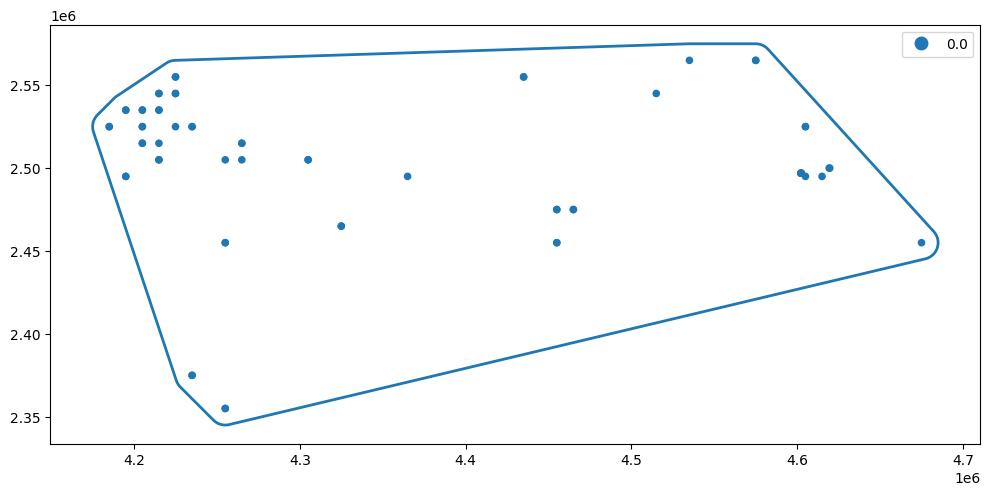

In [ ]:
ax = region_hull_gdf.boundary.plot(
    figsize=(12, 10),
    linewidth=2)

all_points_3035.plot(
    ax=ax,
    column="region_cluster",
    categorical=True,
    markersize=20,
    legend=True
)

Text(104.09722222222221, 0.5, 'Northing (m)')

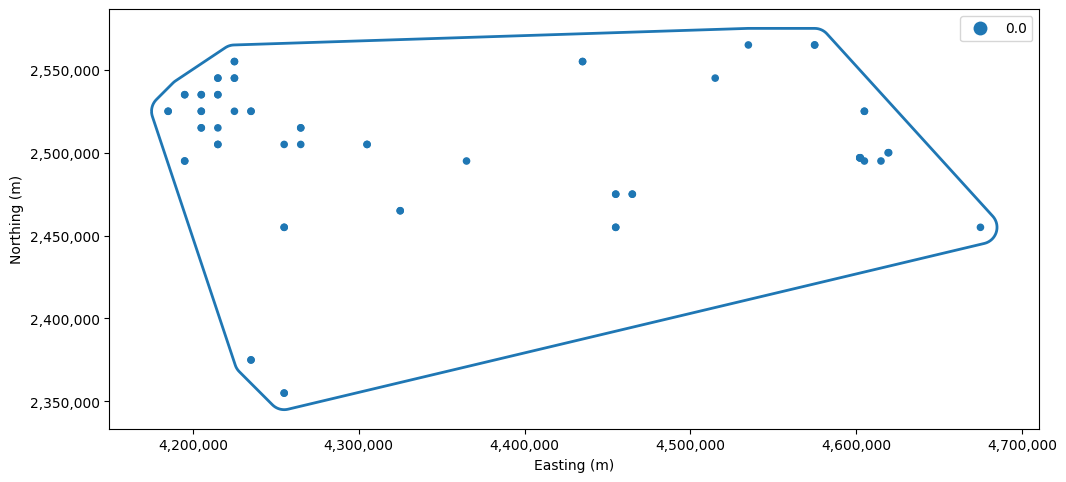

In [ ]:
from matplotlib.ticker import StrMethodFormatter

ax = region_hull_gdf.boundary.plot(
    figsize=(12, 10),
    linewidth=2
)

all_points_3035.plot(
    ax=ax,
    column="region_cluster",
    categorical=True,
    markersize=20,
    legend=True
)

# Format coordinates
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

## Define Study region

In [ ]:
## Generate convex hull for each DBSCAN cluster

region1 = (gdf_3035_sub.geometry.union_all().convex_hull)

region_hull_gdf = gpd.GeoDataFrame(
    {"region_cluster": [0]},
    geometry=[region1],
    crs=gdf_3035_sub.crs
)   ## excluding the buffer

region1 = region1.buffer(40_000)


In [ ]:
#############################################
## study_area_3035

study_area_3035 = gpd.GeoDataFrame(
    geometry=[region1],
    crs=gdf_3035_sub.crs
)

print(study_area_3035.crs)
print(study_area_3035.geometry.geom_type)
print(len(study_area_3035))

##############################################

EPSG:3035
0    Polygon
dtype: object
1


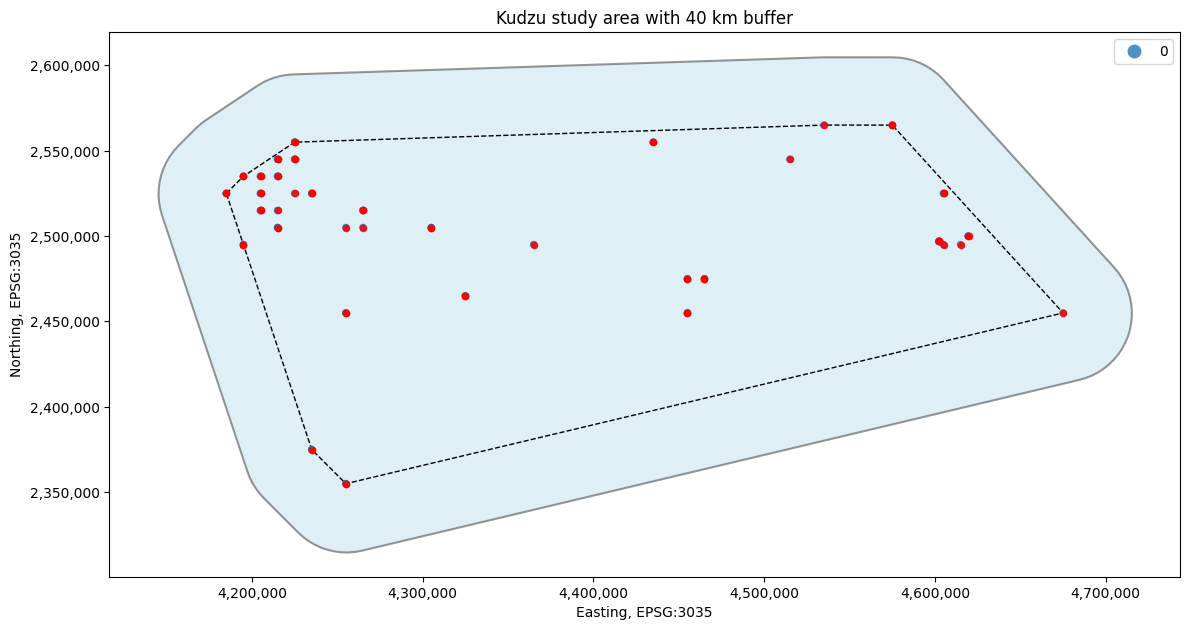

In [ ]:
## Plot study area

fig, ax = plt.subplots(figsize=(12, 8))


study_area_3035.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="black",
    linewidth=1.5,
    alpha=0.4,
    zorder=1
)

region_hull_gdf.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.0,
    linestyle="--",
    zorder=2
)

gdf_3035_sub.plot(
    ax=ax,
    column="region_cluster",
    categorical=True,
    cmap="tab10",
    markersize=20,
    alpha=0.8,
    legend=True,
    zorder=3
)


# Records included in the study area
gdf_3035_sub.plot(
    ax=ax,
    color="red",
    markersize=20,
    alpha=0.8,
    zorder=3
)

ax.set_title("Kudzu study area with 40 km buffer")
ax.set_xlabel("Easting, EPSG:3035")
ax.set_ylabel("Northing, EPSG:3035")
ax.set_aspect("equal")
ax.grid(False)


ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

## Create 10km grid

In [ ]:
### study area and grid parameters

cell_size = 10_000

x_shift = 3200
y_shift = 3000


# Overall extent covering both buffered regions
study_xmin, study_ymin, study_xmax, study_ymax = (
    study_area_3035.total_bounds
)


## create grid
grid_xmin = study_xmin + x_shift
grid_xmax = study_xmax + x_shift
grid_ymin = study_ymin + y_shift
grid_ymax = study_ymax + y_shift

cols = np.arange(
    grid_xmin,
    grid_xmax + cell_size,
    cell_size
)

rows = np.arange(
    grid_ymax,
    grid_ymin - cell_size,
    -cell_size
)

grid_cells = []

for x in cols[:-1]:
    for y in rows[:-1]:

        grid_cells.append(
            box(
                x,
                y - cell_size,
                x + cell_size,
                y
            )
        )

grid3035 = gpd.GeoDataFrame(
    {
        "patch_id": range(len(grid_cells))
    },
    geometry=grid_cells,
    crs="EPSG:3035"
)


########################################
#    grid3035   for grid
########################################

## Keep grid patches intersecting the study area

grid3035 = grid3035[
    grid3035.intersects(
        study_area_3035.geometry.union_all()
    )
].copy()

## Label round-1

grid3035 = grid3035.reset_index(drop=True)

grid3035["patch_id"] = np.arange(len(grid3035))

print("grid3035 rows:", len(grid3035))
print("grid3035 bounds:", grid3035.total_bounds)
print("study area bounds:", study_area_3035.total_bounds)

grid3035 rows: 1284
grid3035 bounds: [4148207.6390238  2317998.95653626 4718207.6390238  2607998.95653626]
study area bounds: [4145007.6390238  2315020.34935584 4714960.49164243 2604998.95653626]


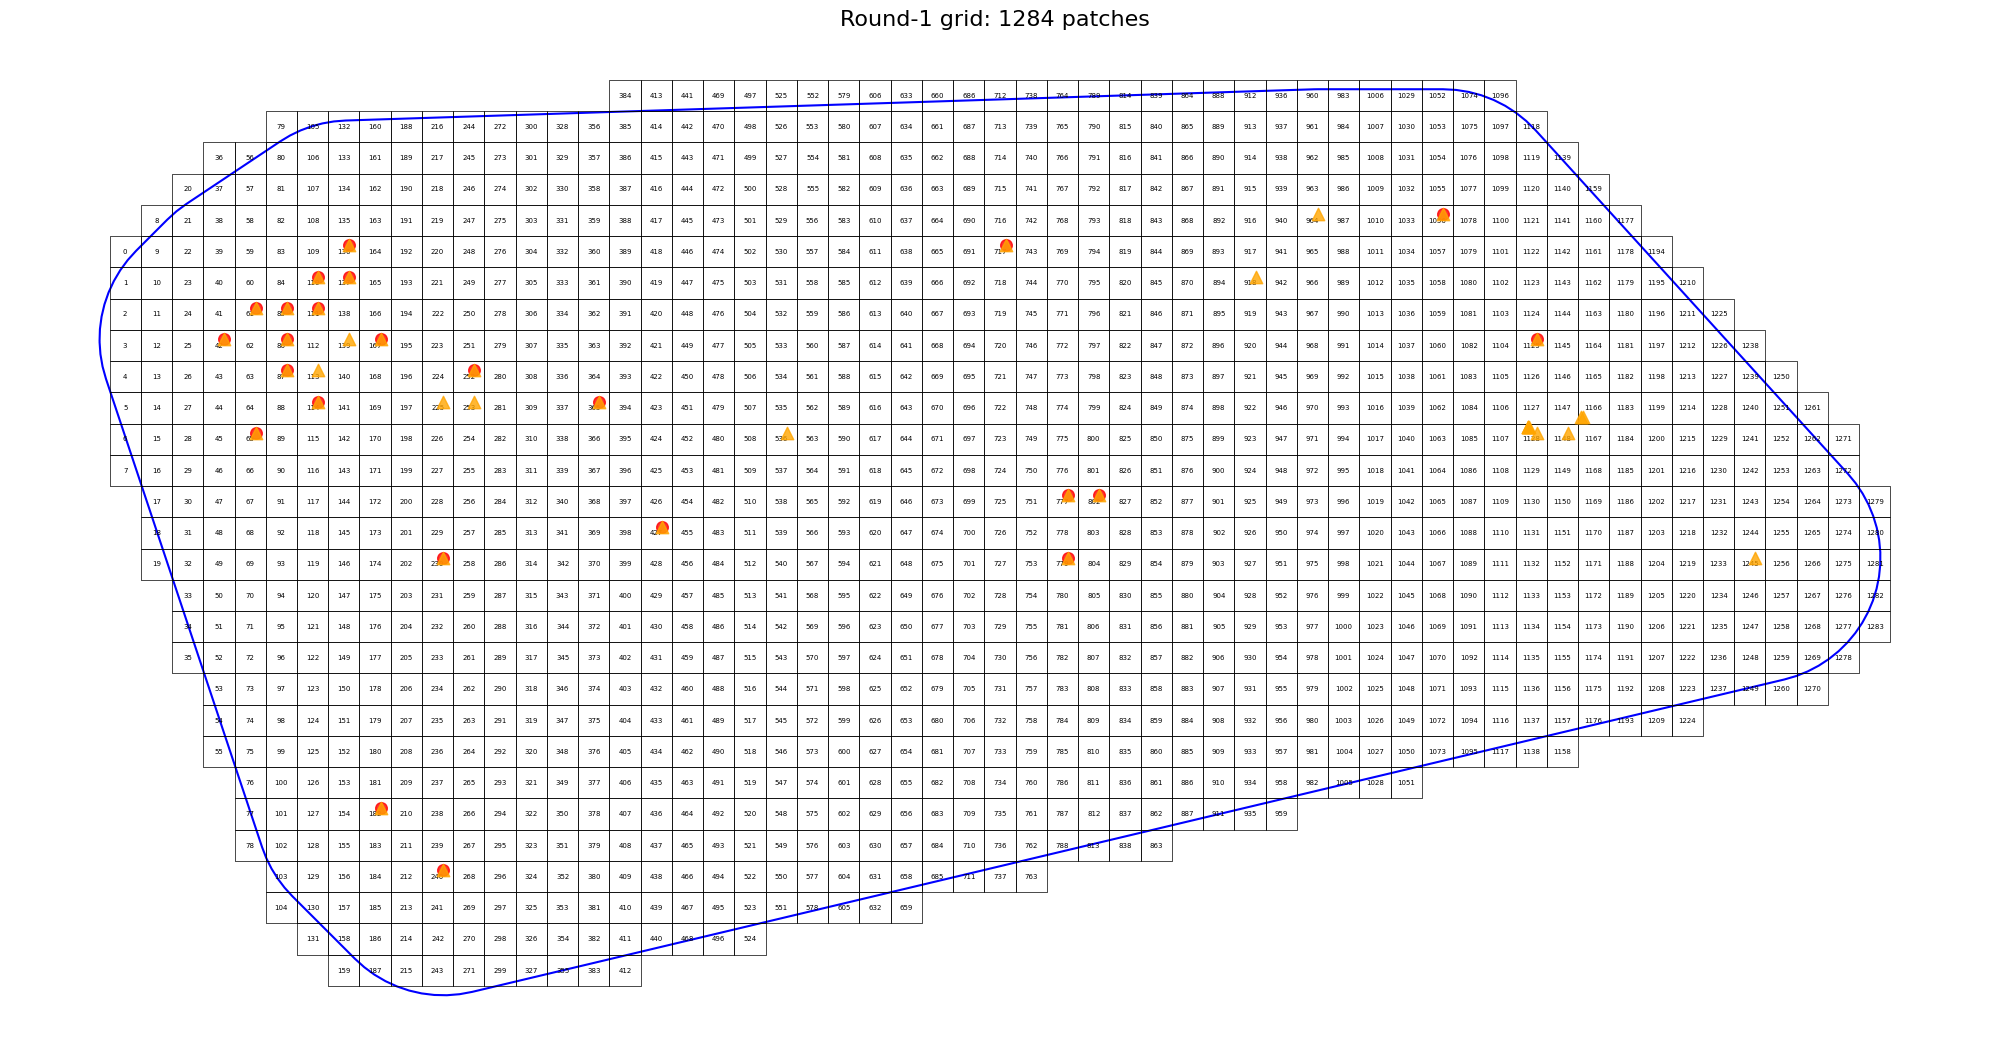

In [ ]:
## Plot grid after round-1 labelling

fig, ax = plt.subplots(figsize=(20, 15))

# Study-area boundary
study_area_3035.boundary.plot(
    ax=ax,
    edgecolor="blue",
    linewidth=1.5,
    zorder=1
)

# Grid patches
grid3035.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5,
    zorder=2
)

gdf_year1_3035.plot(
    ax=ax,
    color="red",
    marker="o",
    markersize=70,
    alpha=0.8,
    zorder=6
)

gdf_year2_3035.plot(
    ax=ax,
    color="orange",
    marker="^",
    markersize=80,
    alpha=0.8,
    zorder=7
)


# Patch IDs
for _, row in grid3035.iterrows():

    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        str(row["patch_id"]),
        fontsize=5,
        color="black",
        ha="center",
        va="center",
        zorder=3
    )

ax.set_title(
    f"Round-1 grid: {len(grid3035)} patches",
    fontsize=16
)

ax.set_aspect("equal")
ax.set_axis_off()

plt.tight_layout()
plt.show()

### Assign data to patch

In [ ]:
##########################################
##    Assign data to patch
##########################################

In [ ]:
# ## Assign Year 1 records to patches

# gdf_year1_3035 = gpd.sjoin(
#     gdf_year1_3035,
#     grid3035[["patch_id", "geometry"]],
#     how="inner",
#     predicate="within"
# )

# gdf_year1_3035 = (
#     gdf_year1_3035
#     .drop(columns="index_right")
#     .reset_index(drop=True)
# )


# ## Assign Year 2 records to patches

# gdf_year2_3035 = gpd.sjoin(
#     gdf_year2_3035,
#     grid3035[["patch_id", "geometry"]],
#     how="inner",
#     predicate="within"
# )

# gdf_year2_3035 = (
#     gdf_year2_3035
#     .drop(columns="index_right")
#     .reset_index(drop=True)
# )


# print("Year 1 assigned records:", len(gdf_year1_3035))
# print("Year 2 assigned records:", len(gdf_year2_3035))

In [ ]:
## Redefine final study area using the Round-1 grid extent

###########   study area     #############################

study_area_3035 = gpd.GeoDataFrame(
    geometry=[box(*grid3035.total_bounds)],
    crs=grid3035.crs
)

print("Final study area bounds:", study_area_3035.total_bounds)
print("Grid bounds:", grid3035.total_bounds)

##########################################################

Final study area bounds: [4148207.6390238  2317998.95653626 4718207.6390238  2607998.95653626]
Grid bounds: [4148207.6390238  2317998.95653626 4718207.6390238  2607998.95653626]




---



#------------------------FLAG HERE, INSERT START ---------------------------

# Import OSM land and water polygons

In [ ]:
study_area_3035.total_bounds

array([4148207.6390238 , 2317998.95653626, 4718207.6390238 ,
       2607998.95653626])

In [ ]:
study_area_4326 = study_area_3035.to_crs("EPSG:4326")
study_area_4326.total_bounds

array([ 7.7483611 , 43.85380972, 15.17005286, 46.5617434 ])

In [ ]:
land = gpd.read_file(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/data/land-polygons-split-4326/land_polygons.shp",bbox=(7, 44, 14.4, 47.2)
)

water = gpd.read_file(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/data/water-polygons-split-4326/water_polygons.shp",bbox=(7, 44, 14.4, 47.2))

In [ ]:
land_3035 = land.to_crs(3035)
water_3035 = water.to_crs(3035)
print(land_3035.total_bounds)
print(water_3035.total_bounds)

[3994582.44391459 2210408.23587858 4715641.76751765 2777841.56058051]
[4157406.06694439 2210263.38020263 4729613.07152471 2527839.68667331]


In [ ]:
# study_area_3035.total_bounds
# array([4145007.6390238 , 2315020.34935584, 4714960.49164243, 2604998.95653626])

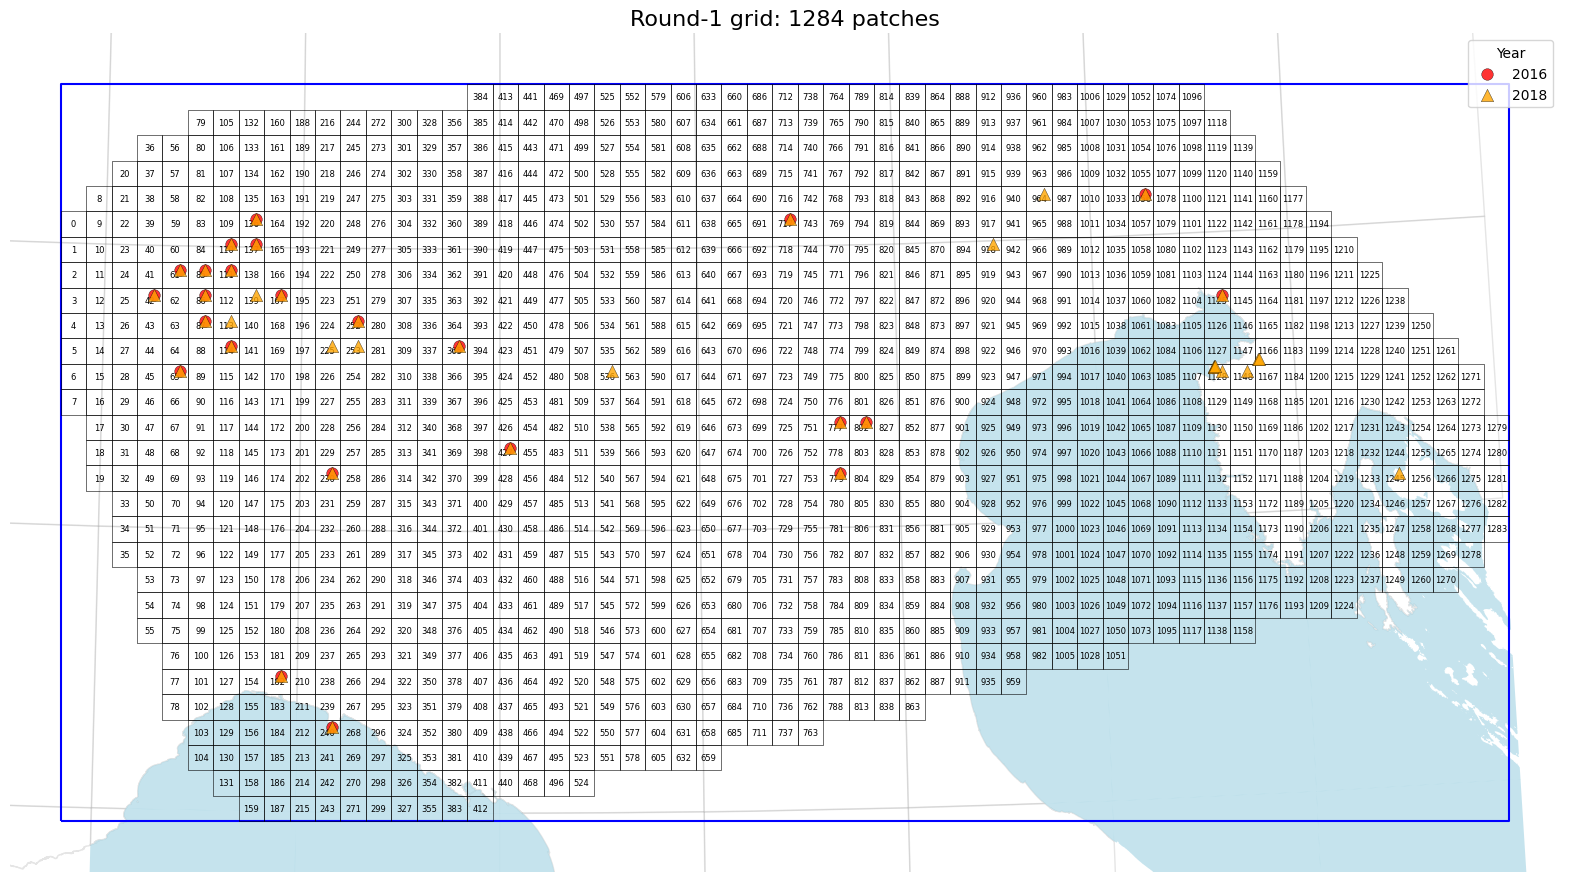

In [ ]:
## Plot grid after round-1 labelling

fig, ax = plt.subplots(figsize=(20, 15))


# OSM land polygons
land_3035.plot(
    ax=ax,
    facecolor="white",
    edgecolor="darkgrey",
    alpha=0.3,
    zorder=1
)


# OSM water polygons
water_3035.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="none",
    alpha=0.7,
    zorder=2
)


# Study-area boundary
study_area_3035.boundary.plot(
    ax=ax,
    edgecolor="blue",
    linewidth=1.5,
    zorder=3
)


# Grid patches
grid3035.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.4,
    zorder=4
)


# Patch IDs
for _, row in grid3035.iterrows():

    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        str(row["patch_id"]),
        fontsize=6,
        color="black",
        ha="center",
        va="center",
        clip_on=True,
        zorder=5
    )


# Year 1 occurrence records
gdf_year1_3035.plot(
    ax=ax,
    color="red",
    marker="o",
    markersize=70,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.8,
    label=str(year1),
    zorder=6
)


# Year 2 occurrence records
gdf_year2_3035.plot(
    ax=ax,
    color="orange",
    marker="^",
    markersize=80,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.8,
    label=str(year2),
    zorder=7
)


# Plot extent based on the study area
xmin, ymin, xmax, ymax = study_area_3035.total_bounds

plot_buffer = 20_000

ax.set_xlim(
    xmin - plot_buffer,
    xmax + plot_buffer
)

ax.set_ylim(
    ymin - plot_buffer,
    ymax + plot_buffer
)


ax.set_title(
    f"Round-1 grid: {len(grid3035)} patches",
    fontsize=16
)

ax.set_aspect("equal")
ax.set_axis_off()

ax.legend(
    title="Year",
    loc="upper right"
)

plt.show()

## Remove Ocean patches

In [ ]:
# Cell area
grid3035["cell_area"] = grid3035.geometry.area


# Intersect grid patches with merged land polygons
grid_land = gpd.overlay(grid3035[["patch_id", "cell_area", "geometry"]],
    gpd.GeoDataFrame(geometry=[land_3035.geometry.union_all()],
                     crs=land_3035.crs),
                        how="intersection",
                        keep_geom_type=True)


# Land area of intersection in each grid
grid_land["land_area"] = grid_land.geometry.area


# Calculate total land area in each grid
land_area = (grid_land.groupby("patch_id", as_index=False)["land_area"].sum()
)


# Join land area back to ###### grid_land3035 ######
grid_land3035 = grid3035.merge(
    land_area,
    on="patch_id",
    how="left"
)


# Patches with no land intersection have zero land area
grid_land3035["land_area"] = (grid_land3035["land_area"].fillna(0))


# Proportion of each patch covered by land
grid_land3035["land_prop"] = ( grid_land3035["land_area"] / grid_land3035["cell_area"])


# Automatically remove patches with no land area
grid_land3035 = grid_land3035[grid_land3035["land_area"] > 0].copy()


In [ ]:
land_area

,patch_id,land_area
0,0,1.000000e+08
1,1,1.000000e+08
2,2,1.000000e+08
3,3,1.000000e+08
4,4,1.000000e+08
...,...,...
1126,1276,4.854095e+06
1127,1279,5.656271e+07
1128,1280,6.296428e+07
1129,1281,6.935743e+07


In [ ]:
# --------------------------------------------------
# Manual adjust patches

add_patch_ids = [1245, 1255, 1256, 1257, 1266, 1267]

remove_patch_ids = [1223, 1224, 1232, 1233, 1234, 1235,
                    1236,1237,1238, 1247,1248, 1249]


# Add selected patches back from the original grid
patches_to_add = grid3035[
    grid3035["patch_id"].isin(add_patch_ids)
].copy()


### Add land-area fields to restored patches
patches_to_add = patches_to_add.merge(
    land_area,
    on="patch_id",
    how="left"
)

patches_to_add["land_area"] = (patches_to_add["land_area"].fillna(0))

patches_to_add["land_prop"] = (patches_to_add["land_area"]
                               / patches_to_add["cell_area"])


# Add manually restored patches back

grid_land3035 = gpd.GeoDataFrame(
    pd.concat([ grid_land3035, patches_to_add],ignore_index=True),
    geometry="geometry", crs=grid3035.crs
)


# Remove duplicates
grid_land3035 = grid_land3035.drop_duplicates(
    subset="patch_id").copy()


# Remove manually excluded patches
grid_land3035 = grid_land3035[
    ~grid_land3035["patch_id"].isin(remove_patch_ids)
].copy()


# Check the adjustment
assert set(add_patch_ids).issubset(set(grid_land3035["patch_id"]))

assert not grid_land3035["patch_id"].isin(remove_patch_ids).any()

assert set(add_patch_ids).isdisjoint(set(remove_patch_ids))

print("Patches after manual adjustment:", len(grid_land3035))


Patches after manual adjustment: 1123


In [ ]:
# --------------------------------------------------
# Sort by original patch ID before final relabelling

grid_land3035 = grid_land3035.reset_index(drop=True)


#####  Assign continuous final patch IDs  #######
grid_land3035["patch_id"] = np.arange(len(grid_land3035))


# Checks
print("Original grid:", len(grid3035))
print("Final retained patches:", len(grid_land3035))
print("Total removed patches:",len(grid3035) - len(grid_land3035))

print("Zero-land patches retained:",
    (grid_land3035["land_area"] <= 0).sum())

print("Duplicate patch IDs:",
    grid_land3035["patch_id"].duplicated().sum())

print("Patch IDs continuous:",
    np.array_equal(grid_land3035["patch_id"].to_numpy(), np.arange(len(grid_land3035)))
)

Original grid: 1284
Final retained patches: 1123
Total removed patches: 161
Zero-land patches retained: 4
Duplicate patch IDs: 0
Patch IDs continuous: True


In [ ]:
print(
    patches_to_add.loc[
        patches_to_add["land_area"] <= 0,
        ["patch_id", "land_area", "land_prop"]
    ].sort_values("patch_id")
)

#### These island patches appear problematic at this stage, but will be resolved after importing CLC

   patch_id  land_area  land_prop
0      1245        0.0        0.0
2      1256        0.0        0.0
3      1257        0.0        0.0
5      1267        0.0        0.0


## Import water surface dataset (EU-Hydro)

In [ ]:
from pyogrio import list_layers

path = "/content/drive/MyDrive/MSC_PROJECT_YJ/data/EU_hydro_gpkg_eu/euhydro_po_v013_GPKG/euhydro_po_v013_GPKG/euhydro_po_v013.gpkg"

list_layers(path)

/usr/local/lib/python3.13/dist-packages/pyogrio/core.py:169: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_list_layers(get_vsi_path_or_buffer(path_or_buffer))
/usr/local/lib/python3.13/dist-packages/pyogrio/core.py:169: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_list_layers(get_vsi_path_or_buffer(path_or_buffer))
/usr/local/lib/python3.13/dist-packages/pyogrio/core.py:169: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_list_layers(get_vsi_path_or_buffer(path_or_buffer))


array([['Canals_l', 'MultiLineString Z'],
       ['Canals_p', 'MultiPolygon Z'],
       ['Coastal_p', 'MultiPolygon Z'],
       ['Culverts', 'Point Z'],
       ['Ditches_l', 'MultiLineString Z'],
       ['Ditches_p', 'MultiPolygon Z'],
       ['InlandWater', 'MultiPolygon Z'],
       ['Nodes', 'Point Z'],
       ['River_Net_l', 'MultiLineString Z'],
       ['River_Net_p', 'MultiPolygon Z'],
       ['RiverBasins', 'MultiPolygon Z'],
       ['Transit_p', 'MultiPolygon Z']], dtype=object)

In [ ]:
warnings.filterwarnings(
    "ignore",
    message="Measured \\(M\\) geometry types are not supported.*"
)
warnings.filterwarnings(
    "ignore",
    message="Non-conformant content for record.*"
)

## import layers
base = "/content/drive/MyDrive/MSC_PROJECT_YJ/data/EU_hydro_gpkg_eu"

gpkg_paths = {
    "danube": f"{base}/euhydro_danube_v013_GPKG/euhydro_danube_v013_GPKG/euhydro_danube_v013.gpkg",
    "po":     f"{base}/euhydro_po_v013_GPKG/euhydro_po_v013_GPKG/euhydro_po_v013.gpkg",
    "rhine":  f"{base}/euhydro_rhine_v013_GPKG/euhydro_rhine_v013_GPKG/euhydro_rhine_v013.gpkg",
    "rhone":  f"{base}/euhydro_rhone_v013_GPKG/euhydro_rhone_v013_GPKG/euhydro_rhone_v013.gpkg",
}


def read_layer_all(layer_name):
    parts = []

    for basin_name, path in gpkg_paths.items():
        gdf_tmp = gpd.read_file(path, layer=layer_name)
        gdf_tmp["source_basin"] = basin_name
        parts.append(gdf_tmp)

    out = gpd.GeoDataFrame(
        pd.concat(parts, ignore_index=True),
        geometry="geometry",
        crs=parts[0].crs
    )

    return out


In [ ]:
bbox = (7, 44, 14.4, 47.2)

In [ ]:
# read layers
eu_basins = read_layer_all("RiverBasins")
eu_inland = read_layer_all("InlandWater")


# convert bbox from EPSG:4326 to EPSG:3035
bbox_3035 = gpd.GeoDataFrame(
    geometry=[box(*bbox)],
    crs="EPSG:4326"
).to_crs(3035)


# clip EU-Hydro layers
basins_clip = gpd.clip(
    eu_basins,
    bbox_3035
)

inland_clip = gpd.clip(
    eu_inland,
    bbox_3035
)

## Clip OSM polygons to the same bbox

land_clip = gpd.clip(
    land_3035,
    bbox_3035
)

water_clip = gpd.clip(
    water_3035,
    bbox_3035
)


print("River basins in bbox:", len(basins_clip))
print("Inland water in bbox:", len(inland_clip))


River basins in bbox: 4
Inland water in bbox: 4129


In [ ]:
# basins_clip
# inland_clip
# land_clip
# water_clip

/tmp/ipykernel_1749/3455428966.py:117: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(


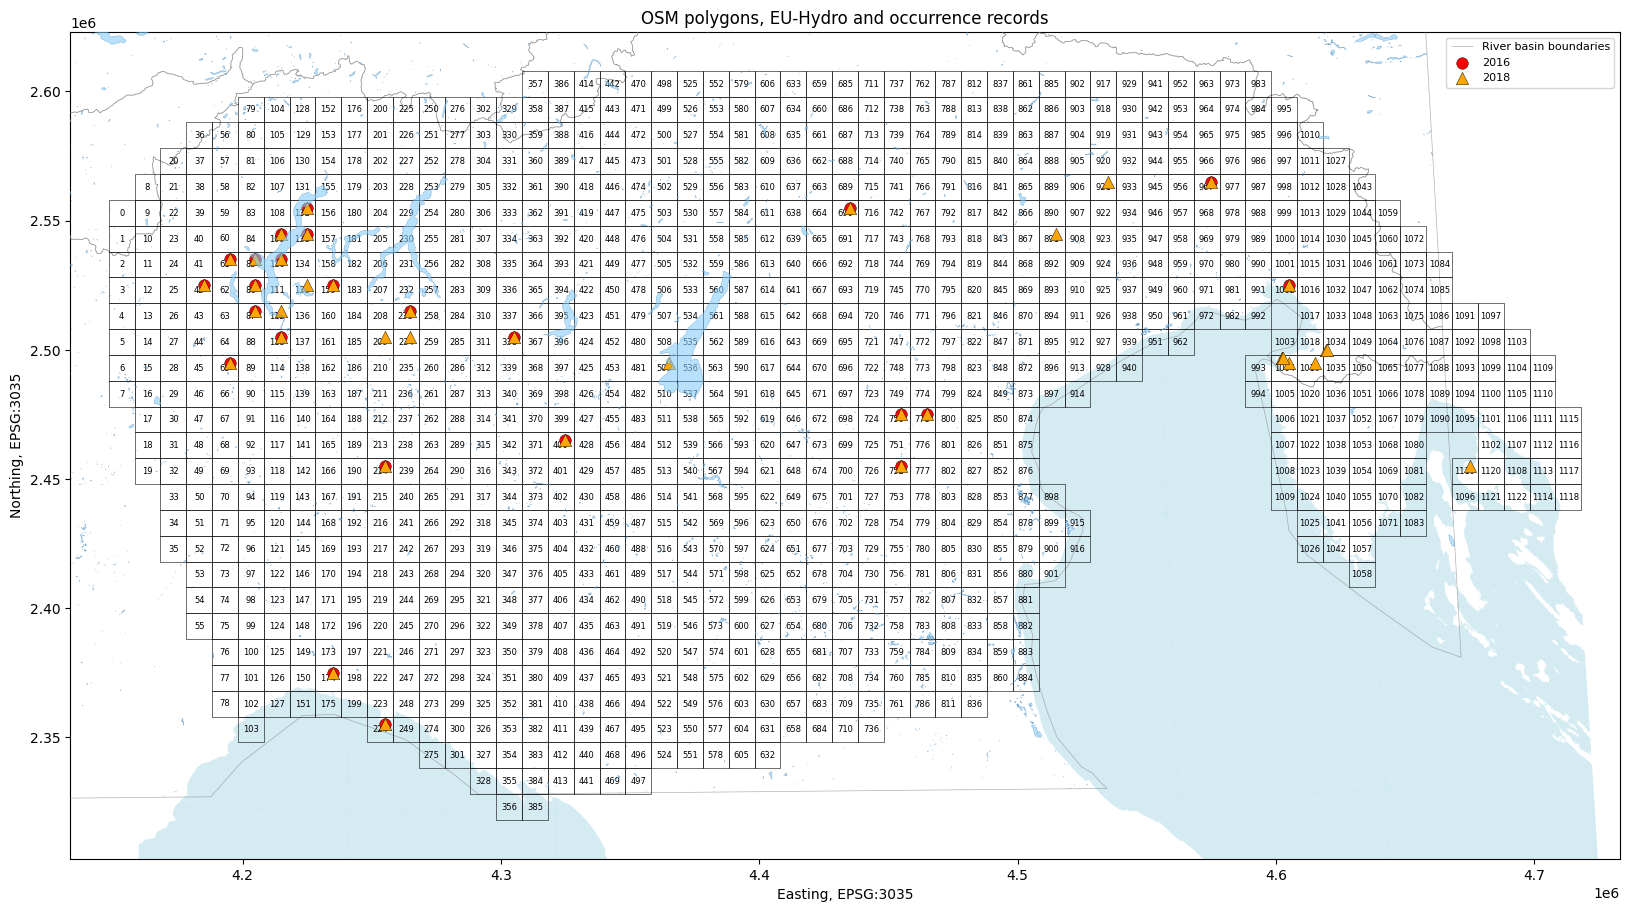

In [ ]:
## Plot patches, OSM polygons, EU-Hydro and occurrence records

fig, ax = plt.subplots(figsize=(20, 15))


# OSM land polygons
land_3035.plot(
    ax=ax,
    facecolor="white",
    edgecolor="none",
    zorder=1
)


# OSM water polygons
water_3035.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="none",
    alpha=0.5,
    zorder=2
)


# EU-Hydro river basin boundaries
basins_clip.boundary.plot(
    ax=ax,
    edgecolor="grey",
    linewidth=0.5,
    alpha=0.6,
    zorder=3,
    label="River basin boundaries"
)


# EU-Hydro inland-water polygons
inland_clip.plot(
    ax=ax,
    facecolor="lightskyblue",
    edgecolor="steelblue",
    linewidth=0.3,
    alpha=0.6,
    zorder=8,
    label="EU-Hydro inland water"
)


# Retained land patches
grid_land3035.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.4,
    zorder=5
)


# Year 1 occurrence records
gdf_year1_3035.plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=0.3,
    markersize=70,
    marker="o",
    label=str(year1),
    zorder=6
)


# Year 2 occurrence records
gdf_year2_3035.plot(
    ax=ax,
    color="orange",
    edgecolor="black",
    linewidth=0.3,
    markersize=80,
    marker="^",
    label=str(year2),
    zorder=7
)


# Patch IDs
for _, row in grid_land3035.iterrows():

    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        str(row["patch_id"]),
        fontsize=6,
        color="black",
        ha="center",
        va="center",
        zorder=3
    )


# Plot extent based on retained patches

xmin, ymin, xmax, ymax = grid_land3035.total_bounds

plot_buffer = 15_000

ax.set_xlim(xmin - plot_buffer, xmax + plot_buffer)
ax.set_ylim(ymin - plot_buffer, ymax + plot_buffer)

ax.set_aspect("equal")


ax.set_title("OSM polygons, EU-Hydro and occurrence records")

ax.set_xlabel("Easting, EPSG:3035")
ax.set_ylabel("Northing, EPSG:3035")

ax.legend(
    loc="upper right",
    fontsize=8,
    frameon=True
)

plt.show()



---



##---------------------- FLAG HERE, INSERT END ------------------------------

# CORINE Landcover

In [ ]:
clc_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/data/CLC2018_geoPackage/DATA/U2018_CLC2018_V2020_20u1.gpkg"
clc_layer = "U2018_CLC2018_V2020_20u1"

In [ ]:
## Read CLC CRS

clc_crs = gpd.read_file(clc_path, layer=clc_layer, rows=1).crs

print("CLC CRS:", clc_crs)

CLC CRS: EPSG:3035


In [ ]:
study_area_3035.total_bounds

array([4148207.6390238 , 2317998.95653626, 4718207.6390238 ,
       2607998.95653626])

In [ ]:
grid_land3035.total_bounds


array([4148207.6390238 , 2317998.95653626, 4718207.6390238 ,
       2607998.95653626])

In [ ]:
## Read CLC for the final study area

bbox = tuple(
    study_area_3035.total_bounds
)

clc = gpd.read_file(
    clc_path,
    layer=clc_layer,
    bbox=bbox,
    columns=["Code_18", "geometry"],
    engine="pyogrio",
    use_arrow=True
)

print("CLC records loaded:", len(clc))

CLC records loaded: 49717


In [ ]:
## Clip CLC to study areas

clc_clip = gpd.clip(clc, study_area_3035)

clc_clip = clc_clip.reset_index(drop=True)

print("CLC after clip:", len(clc_clip))
print(clc_clip.crs)
print(clc_clip["Code_18"].value_counts().head(10))

CLC after clip: 49717
EPSG:3035
Code_18
243    7329
112    5423
324    4903
311    4743
313    4196
242    3720
312    2935
231    2598
211    2501
121    2263
Name: count, dtype: int64


In [ ]:
clc_clip.columns.tolist()

['Code_18', 'geometry']

## Read the legend file

## Define 5 classes of landcover type

In [ ]:
legend_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/data/CLC2018_geoPackage/Legend/clc_legend.xls"

legend = pd.read_excel(legend_path)

print(legend.shape)
print(legend.columns)


(48, 6)
Index(['GRID_CODE', 'CLC_CODE', 'LABEL1', 'LABEL2', 'LABEL3', 'RGB'], dtype='object')


In [ ]:
legend.head(10)

,GRID_CODE,CLC_CODE,LABEL1,LABEL2,LABEL3,RGB
0,1,111,Artificial surfaces,Urban fabric,Continuous urban fabric,230-000-077
1,2,112,Artificial surfaces,Urban fabric,Discontinuous urban fabric,255-000-000
2,3,121,Artificial surfaces,"Industrial, commercial and transport units",Industrial or commercial units,204-077-242
3,4,122,Artificial surfaces,"Industrial, commercial and transport units",Road and rail networks and associated land,204-000-000
4,5,123,Artificial surfaces,"Industrial, commercial and transport units",Port areas,230-204-204
5,6,124,Artificial surfaces,"Industrial, commercial and transport units",Airports,230-204-230
6,7,131,Artificial surfaces,"Mine, dump and construction sites",Mineral extraction sites,166-000-204
7,8,132,Artificial surfaces,"Mine, dump and construction sites",Dump sites,166-077-000
8,9,133,Artificial surfaces,"Mine, dump and construction sites",Construction sites,255-077-255
9,10,141,Artificial surfaces,"Artificial, non-agricultural vegetated areas",Green urban areas,255-166-255


In [ ]:
clc_clip.columns.tolist()

['Code_18', 'geometry']

In [ ]:
legend["land_class"] = ""

# Urban
legend.loc[legend["CLC_CODE"].isin([
    111,112,121,122,123,124,131,132,133,141,142]), "land_class"] = "Urban"

# Agriculture
legend.loc[legend["CLC_CODE"].isin([
    211,212,213,221,222,223,231,241,242,243,244]), "land_class"] = "Agriculture"

# Forest
legend.loc[legend["CLC_CODE"].isin([
    311,312,313,321,322,323,324,331,332,333,334,335]), "land_class"] = "Forest"

# Freshwater
legend.loc[legend["CLC_CODE"].isin([411,412,511,512]), "land_class"] = "Freshwater"

# Marine
legend.loc[legend["CLC_CODE"].isin([421,422,423,521,522,523]), "land_class"] = "Marine"

# Other
legend.loc[legend["CLC_CODE"].isin([990,995,999]), "land_class"] = "Other"

In [ ]:
clc_clip["Code_18"] = clc_clip["Code_18"].astype(int)
legend["CLC_CODE"] = legend["CLC_CODE"].astype(int)

clc_clip = clc_clip.merge(
    legend[["CLC_CODE", "land_class"]],
    left_on="Code_18",
    right_on="CLC_CODE",
    how="left"
)

clc_clip["land_class"].value_counts()

####  could report the biased data here, after merge them  to patch

,count
land_class,
Forest,22362
Agriculture,17590
Urban,9130
Freshwater,498
Marine,137


In [ ]:
print(len(clc))
print(len(clc_clip))

49717
49717


In [ ]:
clc_clip.columns.tolist()

['Code_18', 'geometry', 'CLC_CODE', 'land_class']

In [ ]:
#### Overlay the land-cover polygons with patches

grid_land3035_plus_clc = gpd.overlay(
    grid_land3035[["patch_id", "geometry"]],
    clc_clip[["Code_18", "land_class", "geometry"]],
    how="intersection",
    keep_geom_type=True
)

grid_land3035_plus_clc["clc_area"] = grid_land3035_plus_clc.geometry.area

print(grid_land3035_plus_clc.shape)
print(grid_land3035_plus_clc["land_class"].value_counts())

(55119, 5)
land_class
Forest         24453
Agriculture    18906
Urban          10626
Freshwater       811
Marine           323
Name: count, dtype: int64


In [ ]:
# clc
# clc_clip
# grid_land3035_plus_clc

In [ ]:
## Summary land cover area and proportion for each patch

patch_landcover = (grid_land3035_plus_clc.groupby(["patch_id", "land_class"], as_index=False)["clc_area"].sum())

patch_area = grid_land3035[["patch_id", "geometry"]].copy()

patch_area["cell_area"] = patch_area.geometry.area

patch_landcover = patch_landcover.merge(
    patch_area[["patch_id", "cell_area"]],
    on="patch_id",
    how="left"
)

patch_landcover["clc_prop"] = (patch_landcover["clc_area"] / patch_landcover["cell_area"])

print(patch_landcover.columns.tolist())

patch_landcover.head()

['patch_id', 'land_class', 'clc_area', 'cell_area', 'clc_prop']


,patch_id,land_class,clc_area,cell_area,clc_prop
0,0,Agriculture,2.531998e+06,100000000.0,0.025320
1,0,Forest,9.663946e+07,100000000.0,0.966395
2,0,Urban,8.285401e+05,100000000.0,0.008285
3,1,Forest,1.000000e+08,100000000.0,1.000000
4,2,Agriculture,1.298706e+06,100000000.0,0.012987


In [ ]:
# check the sum of land-cover area for each patch
patch_landcover.groupby("patch_id")["clc_prop"].sum().sort_values().loc[
    lambda x: (x - 1).abs() > 1e-9
]

,clc_prop
patch_id,


# Assign occurence records to study patches

In [ ]:
## Assign Year 1 records to patches

gdf_year1_3035 = gpd.sjoin(
    gdf_year1_3035,
    grid_land3035[["patch_id", "geometry"]],
    how="inner",
    predicate="within"
)

gdf_year1_3035 = (
    gdf_year1_3035
    .drop(columns="index_right")
    .reset_index(drop=True)
)


## Assign Year 2 records to patches

gdf_year2_3035 = gpd.sjoin(
    gdf_year2_3035,
    grid_land3035[["patch_id", "geometry"]],
    how="inner",
    predicate="within"
)

gdf_year2_3035 = (
    gdf_year2_3035
    .drop(columns="index_right")
    .reset_index(drop=True)
)

print("Year 1 assigned records:", len(gdf_year1_3035))
print("Year 2 assigned records:", len(gdf_year2_3035))

Year 1 assigned records: 24
Year 2 assigned records: 40


## Calculate the occupancy

In [ ]:
print(patch_landcover.columns.tolist())
print(grid_land3035.columns.tolist())

['patch_id', 'land_class', 'clc_area', 'cell_area', 'clc_prop']
['patch_id', 'geometry', 'cell_area', 'land_area', 'land_prop']


In [ ]:
## Calculate occupancy

grid_land3035["occyear1"] = (grid_land3035["patch_id"].isin(gdf_year1_3035["patch_id"]).astype(int))

grid_land3035["occyear2"] = (grid_land3035["patch_id"].isin(gdf_year2_3035["patch_id"]).astype(int))


print("Final patches:", len(grid_land3035))
print("Year 1 occupied patches:", grid_land3035["occyear1"].sum())
print("Year 2 occupied patches:", grid_land3035["occyear2"].sum())
print("Year 1 assigned records:", len(gdf_year1_3035))
print("Year 2 assigned records:", len(gdf_year2_3035))

Final patches: 1123
Year 1 occupied patches: 24
Year 2 occupied patches: 35
Year 1 assigned records: 24
Year 2 assigned records: 40


## Merge land-cover area and proportion into patches

In [ ]:
# Merge land-cover area and proportion into patches

patch_landcover_area = (patch_landcover
    .pivot(index="patch_id",
           columns="land_class",
           values="clc_area").fillna(0).add_suffix("_area").reset_index())

patch_landcover_area.columns.name = None


## Convert land-cover proportion to wide format

patch_landcover_prop = (patch_landcover
                        .pivot(index="patch_id",columns="land_class",values="clc_prop").fillna(0).add_suffix("_prop")
                        .reset_index())

patch_landcover_prop.columns.name = None


### merge
grid_land3035 = (grid_land3035
                 .merge(patch_landcover_area, on="patch_id", how="left")
                 .merge(patch_landcover_prop, on="patch_id", how="left")
)

In [ ]:
landcover_area_cols = [
    "Agriculture_area",
    "Forest_area",
    "Freshwater_area",
    "Marine_area",
    "Urban_area"
]

landcover_prop_cols = [
    "Agriculture_prop",
    "Forest_prop",
    "Freshwater_prop",
    "Marine_prop",
    "Urban_prop"
]

grid_land3035[landcover_area_cols + landcover_prop_cols] = grid_land3035[landcover_area_cols + landcover_prop_cols].fillna(0)

In [ ]:
grid_land3035.head()

,patch_id,geometry,cell_area,land_area,land_prop,occyear1,occyear2,Agriculture_area,Forest_area,Freshwater_area,Marine_area,Urban_area,Agriculture_prop,Forest_prop,Freshwater_prop,Marine_prop,Urban_prop
0,0,"POLYGON ((4158207.639 2547998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,2.531998e+06,9.663946e+07,0.0,0.0,828540.11590,0.025320,0.966395,0.0,0.0,0.008285
1,1,"POLYGON ((4158207.639 2537998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,0.000000e+00,1.000000e+08,0.0,0.0,0.00000,0.000000,1.000000,0.0,0.0,0.000000
2,2,"POLYGON ((4158207.639 2527998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,1.298706e+06,9.870129e+07,0.0,0.0,0.00000,0.012987,0.987013,0.0,0.0,0.000000
3,3,"POLYGON ((4158207.639 2517998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,5.383980e+06,9.403906e+07,0.0,0.0,576963.47265,0.053840,0.940391,0.0,0.0,0.005770
4,4,"POLYGON ((4158207.639 2507998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,3.931651e+06,9.606835e+07,0.0,0.0,0.00000,0.039317,0.960683,0.0,0.0,0.000000


In [ ]:
grid_land3035.describe()

,patch_id,cell_area,land_area,land_prop,occyear1,occyear2,Agriculture_area,Forest_area,Freshwater_area,Marine_area,Urban_area,Agriculture_prop,Forest_prop,Freshwater_prop,Marine_prop,Urban_prop
count,1123.000000,1.123000e+03,1.123000e+03,1123.000000,1123.000000,1123.000000,1.123000e+03,1.123000e+03,1.123000e+03,1.123000e+03,1.123000e+03,1123.000000,1123.000000,1123.000000,1123.000000,1123.000000
mean,561.000000,1.000000e+08,9.503384e+07,0.950338,0.021371,0.031167,4.182480e+07,4.444377e+07,1.407342e+06,5.373297e+06,6.950790e+06,0.418248,0.444438,0.014073,0.053733,0.069508
std,324.326482,6.588182e-07,1.901097e+07,0.190110,0.144683,0.173845,3.504351e+07,3.856920e+07,5.362142e+06,1.953240e+07,9.355518e+06,0.350435,0.385692,0.053621,0.195324,0.093555
min,0.000000,1.000000e+08,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,280.500000,1.000000e+08,1.000000e+08,1.000000,0.000000,0.000000,7.546163e+06,2.387319e+06,0.000000e+00,0.000000e+00,1.023586e+06,0.075462,0.023873,0.000000,0.000000,0.010236
50%,561.000000,1.000000e+08,1.000000e+08,1.000000,0.000000,0.000000,3.148232e+07,4.309044e+07,0.000000e+00,0.000000e+00,4.030410e+06,0.314823,0.430904,0.000000,0.000000,0.040304
75%,841.500000,1.000000e+08,1.000000e+08,1.000000,0.000000,0.000000,8.028690e+07,8.422113e+07,6.937802e+05,0.000000e+00,9.025891e+06,0.802869,0.842211,0.006938,0.000000,0.090259
max,1122.000000,1.000000e+08,1.000000e+08,1.000000,1.000000,1.000000,9.896996e+07,1.000000e+08,8.583583e+07,9.985802e+07,7.802438e+07,0.989700,1.000000,0.858358,0.998580,0.780244




---



# Plot land-cover type

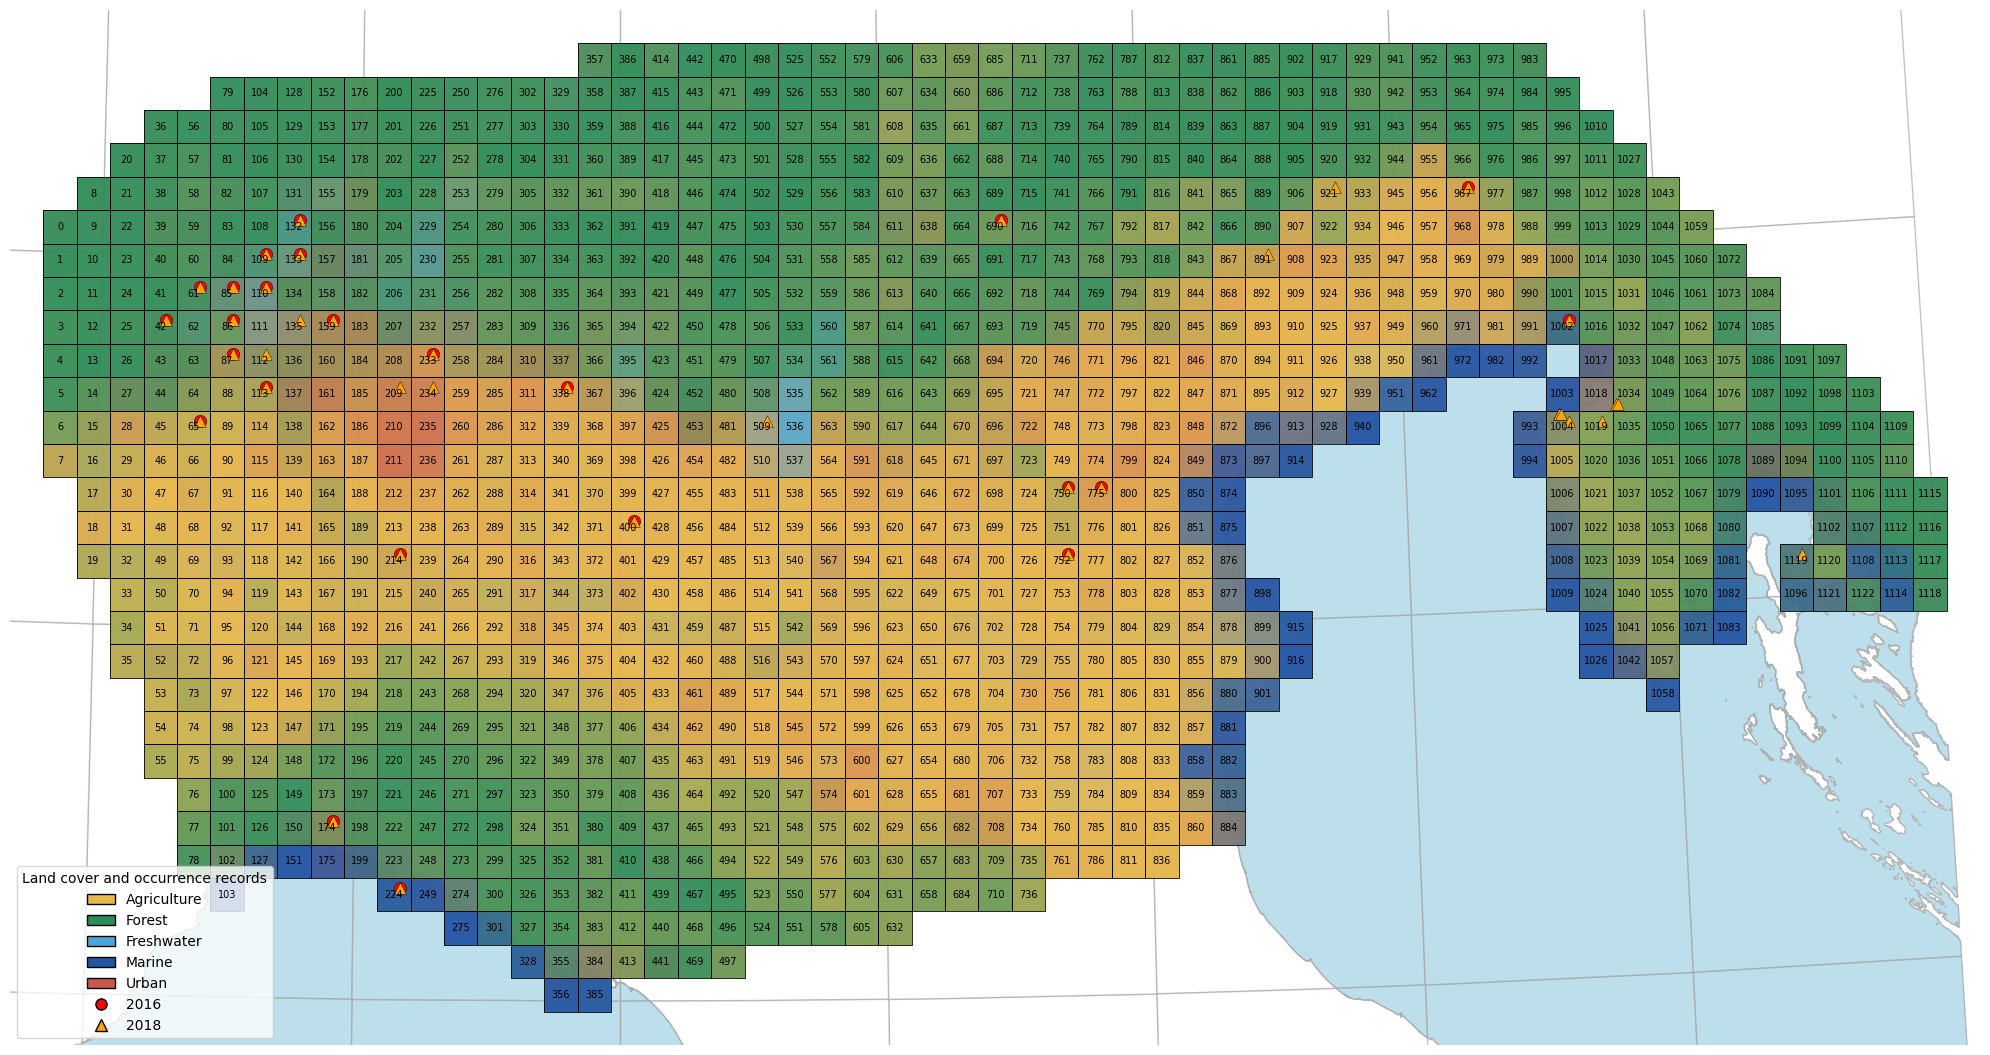

In [ ]:
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

grid_land_plot = grid_land3035.copy()

land_types = [
    "Agriculture",
    "Forest",
    "Freshwater",
    "Marine",
    "Urban"
]

prop_cols = [
    "Agriculture_prop",
    "Forest_prop",
    "Freshwater_prop",
    "Marine_prop",
    "Urban_prop"
]

pure_colours = {
    "Agriculture": "#E6B84A",
    "Forest": "#2E8B57",
    "Freshwater": "#4AA8D8",
    "Marine": "#2455A4",
    "Urban": "#C95A49"
}

colour_matrix = np.array([
    to_rgb(pure_colours[land_type])
    for land_type in land_types
])

# Get proportions
proportions = (
    grid_land_plot[prop_cols]
    .fillna(0)
    .clip(lower=0)
    .to_numpy(dtype=float)
)

# Normalise proportions
row_sums = proportions.sum(axis=1, keepdims=True)

normalised_proportions = np.divide(
    proportions,
    row_sums,
    out=np.zeros_like(proportions),
    where=row_sums != 0
)

# Mix colours
mixed_rgb = normalised_proportions @ colour_matrix

no_data = row_sums.ravel() == 0
mixed_rgb[no_data] = to_rgb("#D9D9D9")

grid_land_plot["mixed_colour"] = [
    tuple(rgb) for rgb in mixed_rgb
]


# Create figure
fig, ax = plt.subplots(figsize=(20, 15))

#==============================================
# land_clip
# water_clip
# basins_clip
# inland_clip


# # OSM land polygons
# land_clip.plot(
#     ax=ax,
#     facecolor="white",
#     edgecolor="none",
#     zorder=1
# )

# OSM water polygons
# water_clip.plot(
#     ax=ax,
#     facecolor="lightblue",
#     edgecolor="none",
#     alpha=0.30,
#     zorder=2
# )


# # River basin boundaries
# basins_clip.boundary.plot(
#     ax=ax,
#     edgecolor="grey",
#     linewidth=0.5,
#     alpha=0.5,
#     zorder=3
# )


# Inland water
# inland_clip.plot(
#     ax=ax,
#     facecolor="lightskyblue",
#     edgecolor="steelblue",
#     linewidth=0.3,
#     alpha=0.5,
#     zorder=3
# )

#----------------------------------
# # Inland water
# eu_inland.plot(
#     ax=ax,
#     facecolor="lightskyblue",
#     edgecolor="steelblue",
#     linewidth=0.3,
#     alpha=0.5,
#     zorder=3
# )

# # River basin boundaries
# eu_basins.boundary.plot(
#     ax=ax,
#     edgecolor="grey",
#     linewidth=0.5,
#     alpha=0.5,
#     zorder=3
# )


#=======================================
# land_3035
# water_3035
# eu_basins
# eu_inland


# OSM land polygons
land_3035.plot(
    ax=ax,
    facecolor="white",
    edgecolor="darkgrey",
    alpha=0.7,
    zorder=1
)

# OSM water polygons
water_3035.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="darkgrey",
    alpha=0.8,
    zorder=2
)




# Land-cover patches
grid_land_plot.plot(
    ax=ax,
    facecolor=grid_land_plot["mixed_colour"].tolist(),
    edgecolor="none",
    alpha=0.95,
    zorder=4
)


# Patch boundaries
grid_land_plot.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.6,
    zorder=5
)


# Year 1 records
gdf_year1_3035.plot(
    ax=ax,
    marker="o",
    color="red",
    markersize=80,
    edgecolor="black",
    linewidth=0.3,
    zorder=7
)


# Year 2 records
gdf_year2_3035.plot(
    ax=ax,
    marker="^",
    color="orange",
    markersize=70,
    edgecolor="black",
    linewidth=0.3,
    zorder=8
)


# Patch labels
for _, row in grid_land_plot.iterrows():

    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        str(row["patch_id"]),
        fontsize=7,
        color="black",
        ha="center",
        va="center",
        zorder=9
    )


# Legend
legend_handles = [
    Patch(
        facecolor=pure_colours[land_type],
        edgecolor="black",
        label=land_type
    )
    for land_type in land_types
]

legend_handles.extend([

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="red",
        markeredgecolor="black",
        markersize=8,
        label=str(year1)
    ),
    Line2D(
        [0],
        [0],
        marker="^",
        linestyle="none",
        markerfacecolor="orange",
        markeredgecolor="black",
        markersize=8,
        label=str(year2)
    )
])

ax.legend(
    handles=legend_handles,
    title="Land cover and occurrence records",
    loc="lower left",
    frameon=True
)


# Set extent
xmin, ymin, xmax, ymax = study_area_3035.total_bounds

plot_buffer = 10_000

ax.set_xlim(
    xmin - plot_buffer,
    xmax + plot_buffer
)

ax.set_ylim(
    ymin - plot_buffer,
    ymax + plot_buffer
)

ax.set_aspect("equal")
# ax.set_title("kudzu vine Land-cover Map")
ax.set_axis_off()

plt.tight_layout()

#--save the image
output_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_landcover_map.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

#-----------------------------
plt.show()

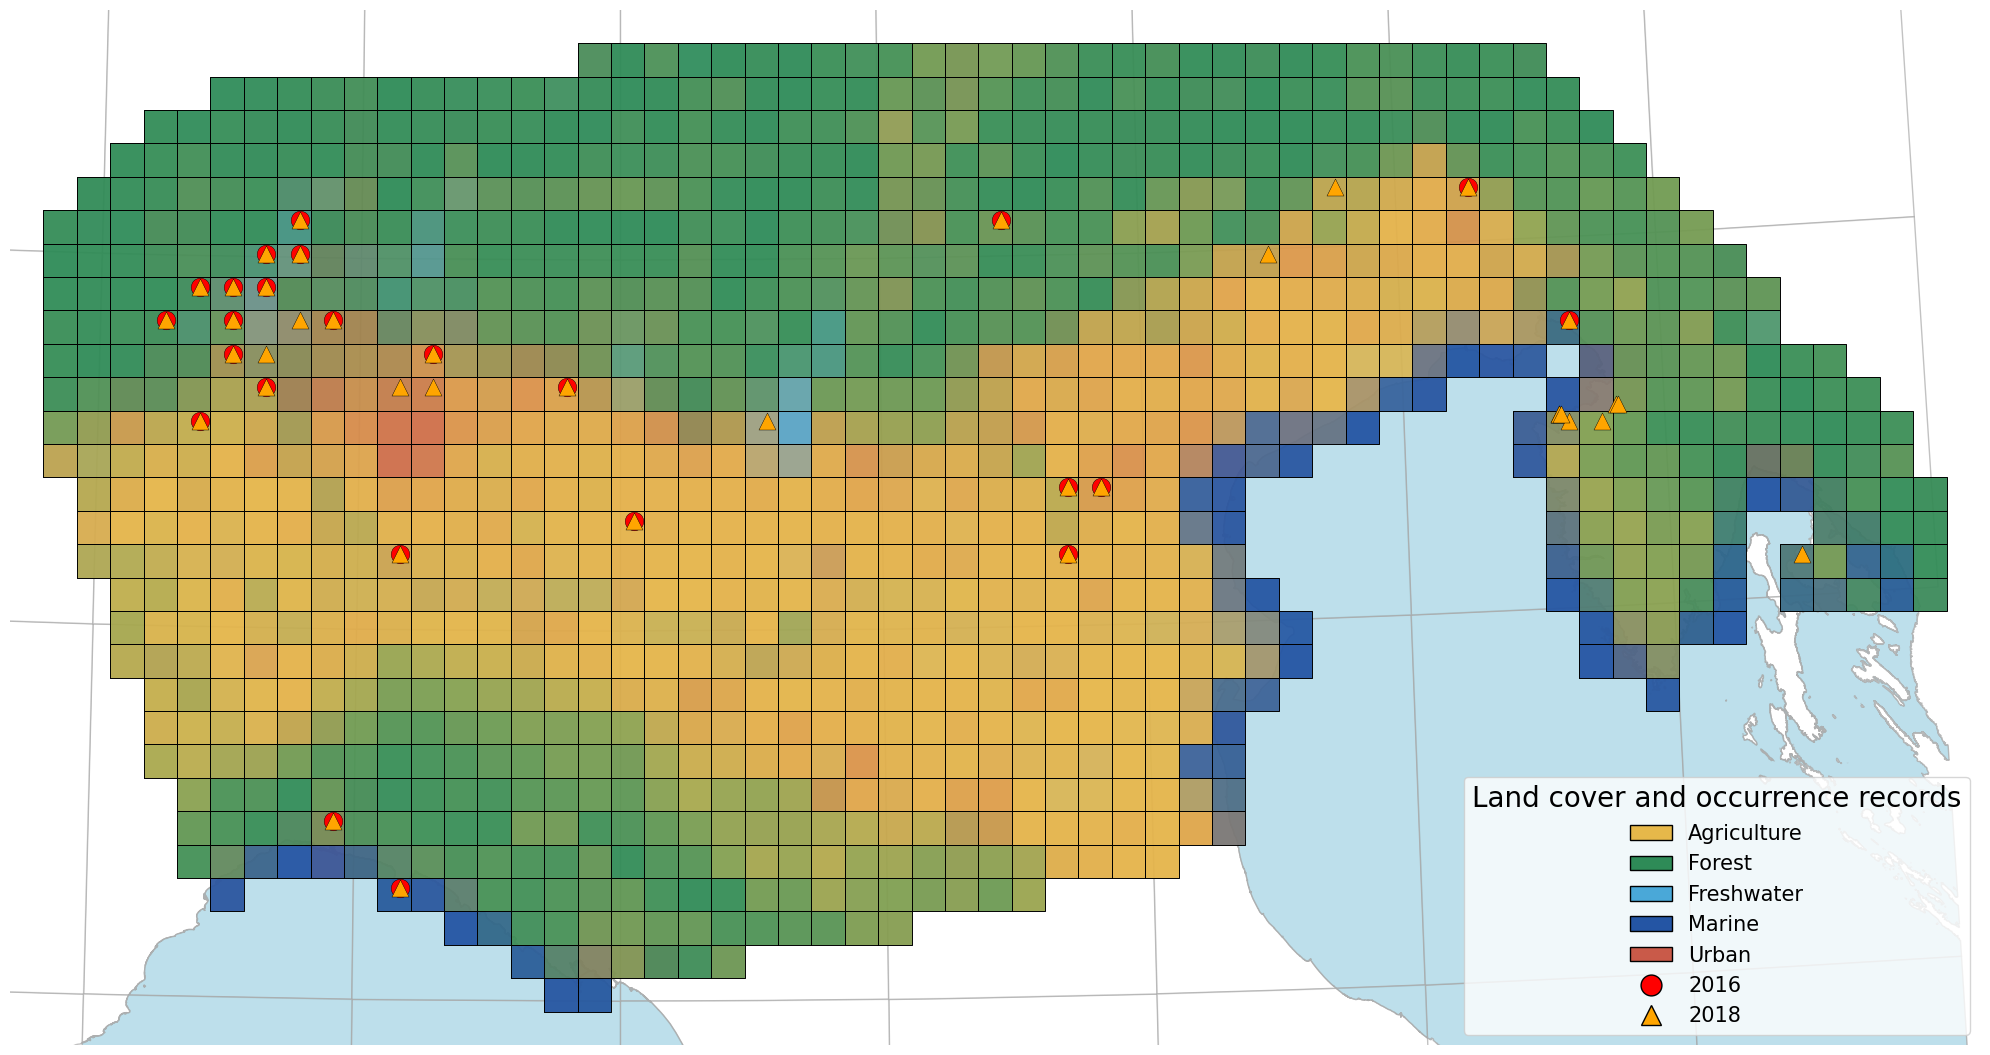

In [ ]:
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

grid_land_plot = grid_land3035.copy()

land_types = [
    "Agriculture",
    "Forest",
    "Freshwater",
    "Marine",
    "Urban"
]

prop_cols = [
    "Agriculture_prop",
    "Forest_prop",
    "Freshwater_prop",
    "Marine_prop",
    "Urban_prop"
]

pure_colours = {
    "Agriculture": "#E6B84A",
    "Forest": "#2E8B57",
    "Freshwater": "#4AA8D8",
    "Marine": "#2455A4",
    "Urban": "#C95A49"
}

colour_matrix = np.array([
    to_rgb(pure_colours[land_type])
    for land_type in land_types
])

# Get proportions
proportions = (
    grid_land_plot[prop_cols]
    .fillna(0)
    .clip(lower=0)
    .to_numpy(dtype=float)
)

# Normalise proportions
row_sums = proportions.sum(axis=1, keepdims=True)

normalised_proportions = np.divide(
    proportions,
    row_sums,
    out=np.zeros_like(proportions),
    where=row_sums != 0
)

# Mix colours
mixed_rgb = normalised_proportions @ colour_matrix

no_data = row_sums.ravel() == 0
mixed_rgb[no_data] = to_rgb("#D9D9D9")

grid_land_plot["mixed_colour"] = [
    tuple(rgb) for rgb in mixed_rgb
]


# Create figure
fig, ax = plt.subplots(figsize=(20, 15))


# OSM land polygons
land_3035.plot(
    ax=ax,
    facecolor="white",
    edgecolor="darkgrey",
    alpha=0.7,
    zorder=1
)

# OSM water polygons
water_3035.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="darkgrey",
    alpha=0.8,
    zorder=2
)




# Land-cover patches
grid_land_plot.plot(
    ax=ax,
    facecolor=grid_land_plot["mixed_colour"].tolist(),
    edgecolor="none",
    alpha=0.95,
    zorder=4
)


# Patch boundaries
grid_land_plot.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.7,
    zorder=5
)


# Year 1 records
gdf_year1_3035.plot(
    ax=ax,
    marker="o",
    color="red",
    markersize=180,
    edgecolor="black",
    linewidth=0.3,
    zorder=7
)


# Year 2 records
gdf_year2_3035.plot(
    ax=ax,
    marker="^",
    color="orange",
    markersize=150,
    edgecolor="black",
    linewidth=0.3,
    zorder=8
)


# # Patch labels
# for _, row in grid_land_plot.iterrows():

#     centroid = row.geometry.centroid

#     ax.text(
#         centroid.x,
#         centroid.y,
#         str(row["patch_id"]),
#         fontsize=7,
#         color="black",
#         ha="center",
#         va="center",
#         zorder=9
#     )


# Legend
legend_handles = [
    Patch(
        facecolor=pure_colours[land_type],
        edgecolor="black",
        label=land_type
    )
    for land_type in land_types
]

legend_handles.extend([

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="red",
        markeredgecolor="black",
        markersize=15,
        label=str(year1)
    ),
    Line2D(
        [0],
        [0],
        marker="^",
        linestyle="none",
        markerfacecolor="orange",
        markeredgecolor="black",
        markersize=15,
        label=str(year2)
    )
])

ax.legend(
    handles=legend_handles,
    title="Land cover and occurrence records",
    loc="lower right",
    frameon=True,
    fontsize=15,
    title_fontsize=20
)


# Set extent
xmin, ymin, xmax, ymax = study_area_3035.total_bounds

plot_buffer = 10_000

ax.set_xlim(
    xmin - plot_buffer,
    xmax + plot_buffer
)

ax.set_ylim(
    ymin - plot_buffer,
    ymax + plot_buffer
)

ax.set_aspect("equal")
# ax.set_title("kudzu vine Land-cover Map")
ax.set_axis_off()

plt.tight_layout()

#--save the image
output_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_landcover_map_without_labels.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

#-----------------------------
plt.show()

# PART 2  Patch attributes

    alpha,

    y_Forest,
    y_Agriculture,
    y_Urban,
    y_Freshwater,
    y_Marine,

    e_Forest,
    e_Agriculture,
    e_Urban,
    e_Freshwater,
    e_Marine,

    x_Forest,
    x_Agriculture,
    x_Urban,
    x_Freshwater,
    x_Marine


In [ ]:
# ############################
# ## parameter cell

# alpha = 0.5
# y = 2.0
# e = 0.002
# x = 0.4

# ############################



---



## Calculate the state of patch $i$ occupancy $O_i$

In [ ]:
# ## RECALL
# # Calculate occupancy

# grid_land3035["occyear1"] = (grid_land3035["patch_id"].isin(gdf_year1_3035["patch_id"]).astype(int))

# grid_land3035["occyear2"] = (grid_land3035["patch_id"].isin(gdf_year2_3035["patch_id"]).astype(int))

occyear1 = (grid_land3035.sort_values("patch_id")["occyear1"].to_numpy())
occyear2 = (grid_land3035.sort_values("patch_id")["occyear2"].to_numpy())


## Calculate patch area $A_i$

In [ ]:
grid_land3035.head()

,patch_id,geometry,cell_area,land_area,land_prop,occyear1,occyear2,Agriculture_area,Forest_area,Freshwater_area,Marine_area,Urban_area,Agriculture_prop,Forest_prop,Freshwater_prop,Marine_prop,Urban_prop
0,0,"POLYGON ((4158207.639 2547998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,2.531998e+06,9.663946e+07,0.0,0.0,828540.11590,0.025320,0.966395,0.0,0.0,0.008285
1,1,"POLYGON ((4158207.639 2537998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,0.000000e+00,1.000000e+08,0.0,0.0,0.00000,0.000000,1.000000,0.0,0.0,0.000000
2,2,"POLYGON ((4158207.639 2527998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,1.298706e+06,9.870129e+07,0.0,0.0,0.00000,0.012987,0.987013,0.0,0.0,0.000000
3,3,"POLYGON ((4158207.639 2517998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,5.383980e+06,9.403906e+07,0.0,0.0,576963.47265,0.053840,0.940391,0.0,0.0,0.005770
4,4,"POLYGON ((4158207.639 2507998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,3.931651e+06,9.606835e+07,0.0,0.0,0.00000,0.039317,0.960683,0.0,0.0,0.000000


In [ ]:
grid_land3035.columns.tolist()

['patch_id',
 'geometry',
 'cell_area',
 'land_area',
 'land_prop',
 'occyear1',
 'occyear2',
 'Agriculture_area',
 'Forest_area',
 'Freshwater_area',
 'Marine_area',
 'Urban_area',
 'Agriculture_prop',
 'Forest_prop',
 'Freshwater_prop',
 'Marine_prop',
 'Urban_prop']

In [ ]:
## Calculate patch area using terrestrial CLC classes

grid_land3035["A_i"] = (
    grid_land3035["Agriculture_area"]
    + grid_land3035["Forest_area"]
    + grid_land3035["Urban_area"]
) / 1_000_000

print(grid_land3035["A_i"].describe())
print("patch area <= 0:", (grid_land3035["A_i"] <= 0).sum())

count    1123.000000
mean       93.219361
std        20.006007
min         0.141981
25%        98.494107
50%       100.000000
75%       100.000000
max       100.000000
Name: A_i, dtype: float64
patch area <= 0: 0


## Calculate patch distance $D_{ij}$

In [ ]:
# ## Infinite-distance matrix

# n_patches = len(grid_land3035)

# D_ij_inf = np.full((n_patches, n_patches), np.inf, dtype=float)
# np.fill_diagonal(D_ij_inf, 0.0)

# print("D_ij_inf shape:", D_ij_inf.shape)

In [ ]:
## 1 Sort patches

grid_land3035 = grid_land3035.sort_values("patch_id").reset_index(drop=True)

print("Total patches:", len(grid_land3035))
print("Unique patch IDs:", grid_land3035["patch_id"].nunique())


#-------------------------------------------------------------

## 2 Extract terrestrial CLC geometry within each patch

grid_land_geom = (
    grid_land3035_plus_clc[
        grid_land3035_plus_clc["land_class"].isin(
            ["Agriculture", "Forest", "Urban"]
        )
    ]
    .dissolve(by="patch_id")
    .reset_index()
)

print("Patches with terrestrial geometry:", len(grid_land_geom))

#-------------------------------------------------------------
## 3 Calculate land centroids

grid_land_geom["land_centroid"] = grid_land_geom.geometry.centroid


#-------------------------------------------------------------
## 4 Join land centroids back to patches

grid_land3035 = grid_land3035.drop(columns="land_centroid", errors="ignore")

grid_land3035 = (grid_land3035.merge(
    grid_land_geom[["patch_id", "land_centroid"]],
    on="patch_id",
    how="left").sort_values("patch_id").reset_index(drop=True)
)

print("Missing land centroids:", grid_land3035["land_centroid"].isna().sum())






#-------------------------------------------------------------
## 5 Map patch_id to matrix index

patch_id_to_idx = {}

for index, patch_id in enumerate(grid_land3035["patch_id"]):
    patch_id_to_idx[patch_id] = index

print("Patch ID mapping:", list(patch_id_to_idx.items())[:5])


#-------------------------------------------------------------
## 6 Extract land-centroid coordinates

land_centroid_x = grid_land3035["land_centroid"].x.to_numpy()
land_centroid_y = grid_land3035["land_centroid"].y.to_numpy()

print("Land centroid x:", land_centroid_x[:5])
print("Land centroid y:", land_centroid_y[:5])


#-------------------------------------------------------------
## 7 Find adjacent patches

neighbors = gpd.sjoin(
    grid_land3035[["patch_id", "geometry"]],
    grid_land3035[["patch_id", "geometry"]],
    how="inner",
    predicate="touches",
    lsuffix="left",
    rsuffix="right"
)

neighbors = neighbors[
    neighbors["patch_id_left"] != neighbors["patch_id_right"]
].copy()

print("Neighbor records:", neighbors.shape)
print(neighbors[["patch_id_left", "patch_id_right"]].head())


#-------------------------------------------------------------
## 8 Create weighted adjacency matrix

from scipy.sparse import lil_matrix, csr_matrix

n_patches = len(grid_land3035)
adjacency_matrix = lil_matrix((n_patches, n_patches), dtype=float)

print("Adjacency matrix shape:", adjacency_matrix.shape)


#-------------------------------------------------------------
## 9 Add land-centroid distances to adjacency matrix

for _, row in neighbors.iterrows():

    patch_id_i = row["patch_id_left"]
    patch_id_j = row["patch_id_right"]

    index_i = patch_id_to_idx[patch_id_i]
    index_j = patch_id_to_idx[patch_id_j]

    distance_km = np.sqrt((land_centroid_x[index_i] - land_centroid_x[index_j]) ** 2 + (land_centroid_y[index_i] - land_centroid_y[index_j]) ** 2) / 1000


    adjacency_matrix[index_i, index_j] = distance_km
    adjacency_matrix[index_j, index_i] = distance_km


#-------------------------------------------------------------
## 10 Convert adjacency matrix to CSR format

adjacency_matrix = csr_matrix(adjacency_matrix)

print("Non-zero directed edges:", adjacency_matrix.nnz)
print("Undirected edges:", adjacency_matrix.nnz // 2)


#-------------------------------------------------------------
## 11 Calculate shortest-path distance matrix

from scipy.sparse.csgraph import shortest_path

D_ij, predecessors = shortest_path(
    csgraph=adjacency_matrix,
    directed=False,
    method="D",
    return_predecessors=True
)


#-------------------------------------------------------------
## 12 Check distance matrix

print("D_ij shape:", D_ij.shape)
print("Diagonal all zero:", np.allclose(np.diag(D_ij), 0))
print("D_ij symmetric:", np.allclose(D_ij, D_ij.T))
print("Infinite distances:", np.isinf(D_ij).sum())

finite_D = D_ij[np.isfinite(D_ij)]
print("Maximum finite distance:", finite_D.max())


#-------------------------------------------------------------
## 13 Re-extract occupancy arrays in the same patch order

occyear1 = grid_land3035["occyear1"].to_numpy()
occyear2 = grid_land3035["occyear2"].to_numpy()

print("Year 1 occupied patches:", occyear1.sum())
print("Year 2 occupied patches:", occyear2.sum())


#-------------------------------------------------------------
## 14 Check alignment

assert grid_land3035["patch_id"].is_unique
assert grid_land3035["land_centroid"].notna().all()
assert D_ij.shape == (len(grid_land3035), len(grid_land3035))
assert len(occyear1) == len(grid_land3035)
assert len(occyear2) == len(grid_land3035)


Total patches: 1123
Unique patch IDs: 1123
Patches with terrestrial geometry: 1123
Missing land centroids: 0
Patch ID mapping: [(0, 0), (1, 1), (2, 2), (3, 3), (4, 4)]
Land centroid x: [4153207.6390238 4153207.6390238 4153207.6390238 4153207.6390238
 4153207.6390238]
Land centroid y: [2552998.95653626 2542998.95653626 2532998.95653626 2522998.95653626
 2512998.95653626]
Neighbor records: (8454, 4)
   patch_id_left  patch_id_right
0              0               1
0              0              10
0              0               9
0              0               8
1              1               2
Adjacency matrix shape: (1123, 1123)
Non-zero directed edges: 8454
Undirected edges: 4227
D_ij shape: (1123, 1123)
Diagonal all zero: True
D_ij symmetric: True
Infinite distances: 0
Maximum finite distance: 604.7918851154399
Year 1 occupied patches: 24
Year 2 occupied patches: 35




---



# Save outputs

In [ ]:
grid_land3035.columns.tolist()

['patch_id',
 'geometry',
 'cell_area',
 'land_area',
 'land_prop',
 'occyear1',
 'occyear2',
 'Agriculture_area',
 'Forest_area',
 'Freshwater_area',
 'Marine_area',
 'Urban_area',
 'Agriculture_prop',
 'Forest_prop',
 'Freshwater_prop',
 'Marine_prop',
 'Urban_prop',
 'A_i',
 'land_centroid']

In [ ]:
import os

print(os.getcwd())

/content


In [ ]:
os.listdir("/content/drive/MyDrive/MSC_PROJECT_YJ")

['data',
 'outputs',
 'Hornet_code',
 'Kudzu_code',
 'backup',
 'FINAL_CODE',
 'outputs_archived']

In [ ]:
# ## Save distance matrices
# n_patches = len(grid_land3035)

# kudzu_D_ij_shortest = D_ij.copy()

# output_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"

# np.save(output_path + "kudzu_D_ij_shortest_V5.npy", kudzu_D_ij_shortest)


In [ ]:
# #-------------------------------------------------------------
# ## Save patch attributes

# kudzu_patch_attributes = grid_land3035[[
#     "patch_id",
#     "cell_area",
#     "land_area",
#     "land_prop",
#     "occyear1",
#     "occyear2",
#     "Agriculture_area",
#     "Forest_area",
#     "Freshwater_area",
#     "Marine_area",
#     "Urban_area",
#     "Agriculture_prop",
#     "Forest_prop",
#     "Freshwater_prop",
#     "Marine_prop",
#     "Urban_prop",
#     "A_i"
# ]].copy()

# kudzu_patch_attributes = (
#     kudzu_patch_attributes
#     .sort_values("patch_id")
#     .reset_index(drop=True)
# )

# output_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"

# kudzu_patch_attributes.to_csv(
#     output_path + "kudzu_patch_attributes_V5.csv",
#     index=False
# )

# print("Patch attributes shape:", kudzu_patch_attributes.shape)

In [ ]:
# import os
# import geopandas as gpd
# from shapely import make_valid


# output_gpkg = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
#     "kudzu_plot_layers.gpkg")


# # ------------------------------------------------------------
# # Helper function: repair geometries

# def repair_geometry(gdf):

#     gdf = gdf.copy()

#     gdf["geometry"] = gdf.geometry.apply(
#         lambda g: make_valid(g) if g is not None else None
#     )

#     gdf = gdf[
#         gdf.geometry.notna()
#         & ~gdf.geometry.is_empty
#     ].copy()

#     return gdf


# # ------------------------------------------------------------
# # Remove old GPKG if rerunning

# if os.path.exists(output_gpkg):
#     os.remove(output_gpkg)


# # ------------------------------------------------------------
# # Repair study area

# study_area_plot = repair_geometry(
#     study_area_3035
# )


# # ------------------------------------------------------------
# # 1. Patches

# kudzu_patches = (
#     grid_land3035
#     .sort_values("patch_id")
#     .reset_index(drop=True)
#     .copy()
# )


# # Main geometry column

# main_geometry = kudzu_patches.geometry.name

# extra_geometry_cols = [
#     col for col in kudzu_patches.columns
#     if str(kudzu_patches[col].dtype) == "geometry"
#     and col != main_geometry
# ]

# print("Main geometry:", main_geometry)
# print("Extra geometry columns:", extra_geometry_cols)


# # Convert extra geometry columns
# # e.g. land_centroid

# for col in extra_geometry_cols:
#     kudzu_patches[col] = kudzu_patches[col].to_wkt()


# # Repair patch geometry

# kudzu_patches = repair_geometry(
#     kudzu_patches
# )


# # Check patch IDs before saving

# assert kudzu_patches["patch_id"].is_unique

# assert (
#     kudzu_patches["patch_id"].to_numpy()
#     == range(len(kudzu_patches))
# ).all()


# kudzu_patches.to_file(
#     output_gpkg,
#     layer="patches",
#     driver="GPKG"
# )


# # ------------------------------------------------------------
# # 2. Land background
# #
# # IMPORTANT:
# # use land_3035 rather than land_clip,
# # because land_clip was clipped using the earlier manual bbox.

# land_fixed = repair_geometry(
#     land_3035
# )

# land_plot = gpd.clip(
#     land_fixed,
#     study_area_plot
# )[["geometry"]].copy()

# land_plot = repair_geometry(
#     land_plot
# )

# land_plot.to_file(
#     output_gpkg,
#     layer="land",
#     driver="GPKG"
# )


# # ------------------------------------------------------------
# # 3. Water background

# water_fixed = repair_geometry(
#     water_3035
# )

# water_plot = gpd.clip(
#     water_fixed,
#     study_area_plot
# )[["geometry"]].copy()

# water_plot = repair_geometry(
#     water_plot
# )

# water_plot.to_file(
#     output_gpkg,
#     layer="water",
#     driver="GPKG"
# )


# # ------------------------------------------------------------
# # 4. Study-area extent

# study_area_plot.to_file(
#     output_gpkg,
#     layer="study_area",
#     driver="GPKG"
# )


# # ------------------------------------------------------------
# # 5. EU-Hydro inland water

# inland_fixed = repair_geometry(
#     eu_inland
# )

# inland_plot = gpd.clip(
#     inland_fixed,
#     study_area_plot
# )[["geometry"]].copy()

# inland_plot = repair_geometry(
#     inland_plot
# )

# inland_plot.to_file(
#     output_gpkg,
#     layer="inland_water",
#     driver="GPKG"
# )




# # ------------------------------------------------------------
# # Summary

# print("Saved:", output_gpkg)

# print("Patches:", len(kudzu_patches))

# print("CRS:", kudzu_patches.crs)

# print(
#     "Patch ID range:",
#     kudzu_patches["patch_id"].min(),
#     "-",
#     kudzu_patches["patch_id"].max()
# )

# print(
#     "2016 occupied patches:",
#     kudzu_patches["occyear1"].sum()
# )

# print(
#     "2018 occupied patches:",
#     kudzu_patches["occyear2"].sum()
# )

# print(
#     "Columns:",
#     kudzu_patches.columns.tolist()
# )



---


# Patch Description

In [ ]:
grid_land3035.head()

,patch_id,geometry,cell_area,land_area,land_prop,occyear1,occyear2,Agriculture_area,Forest_area,Freshwater_area,Marine_area,Urban_area,Agriculture_prop,Forest_prop,Freshwater_prop,Marine_prop,Urban_prop,A_i,land_centroid
0,0,"POLYGON ((4158207.639 2547998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,2.531998e+06,9.663946e+07,0.0,0.0,828540.11590,0.025320,0.966395,0.0,0.0,0.008285,100.0,POINT (4153207.639 2552998.957)
1,1,"POLYGON ((4158207.639 2537998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,0.000000e+00,1.000000e+08,0.0,0.0,0.00000,0.000000,1.000000,0.0,0.0,0.000000,100.0,POINT (4153207.639 2542998.957)
2,2,"POLYGON ((4158207.639 2527998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,1.298706e+06,9.870129e+07,0.0,0.0,0.00000,0.012987,0.987013,0.0,0.0,0.000000,100.0,POINT (4153207.639 2532998.957)
3,3,"POLYGON ((4158207.639 2517998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,5.383980e+06,9.403906e+07,0.0,0.0,576963.47265,0.053840,0.940391,0.0,0.0,0.005770,100.0,POINT (4153207.639 2522998.957)
4,4,"POLYGON ((4158207.639 2507998.957, 4158207.639...",100000000.0,100000000.0,1.0,0,0,3.931651e+06,9.606835e+07,0.0,0.0,0.00000,0.039317,0.960683,0.0,0.0,0.000000,100.0,POINT (4153207.639 2512998.957)


In [ ]:
land_types = [
    "Agriculture",
    "Forest",
    "Freshwater",
    "Marine",
    "Urban"
]

summary_table = pd.DataFrame({
    "Land-cover type": land_types,

    "Mean proportion": [
        grid_land3035[f"{x}_prop"].mean()
        for x in land_types
    ],

    "Mean area (km²)": [
        grid_land3035[f"{x}_area"].mean() / 1_000_000
        for x in land_types
    ],

    "Occupied mean proportion": [
        grid_land3035.loc[
            grid_land3035["occyear2"] == 1,
            f"{x}_prop"
        ].mean()
        for x in land_types
    ],

    "Occupied mean area (km²)": [
        grid_land3035.loc[
            grid_land3035["occyear2"] == 1,
            f"{x}_area"
        ].mean() / 1_000_000
        for x in land_types
    ],

    "Unoccupied mean proportion": [
        grid_land3035.loc[
            grid_land3035["occyear2"] == 0,
            f"{x}_prop"
        ].mean()
        for x in land_types
    ],

    "Unoccupied mean area (km²)": [
        grid_land3035.loc[
            grid_land3035["occyear2"] == 0,
            f"{x}_area"
        ].mean() / 1_000_000
        for x in land_types
    ]
})

summary_table.round(4)

,Land-cover type,Mean proportion,Mean area (km²),Occupied mean proportion,Occupied mean area (km²),Unoccupied mean proportion,Unoccupied mean area (km²)
0,Agriculture,0.4182,41.8248,0.3748,37.4818,0.4196,41.9645
1,Forest,0.4444,44.4438,0.3265,32.6473,0.4482,44.8233
2,Freshwater,0.0141,1.4073,0.0641,6.4129,0.0125,1.2463
3,Marine,0.0537,5.3733,0.0616,6.1611,0.0535,5.3480
4,Urban,0.0695,6.9508,0.1730,17.2969,0.0662,6.6180


            Agriculture    Forest  Freshwater    Marine     Urban
Mean           0.418248  0.444438    0.014073  0.053733  0.069508
Occupied       0.374818  0.326473    0.064129  0.061611  0.172969
Unoccupied     0.419645  0.448233    0.012463  0.053480  0.066180
Mean          1.0
Occupied      1.0
Unoccupied    1.0
dtype: float64


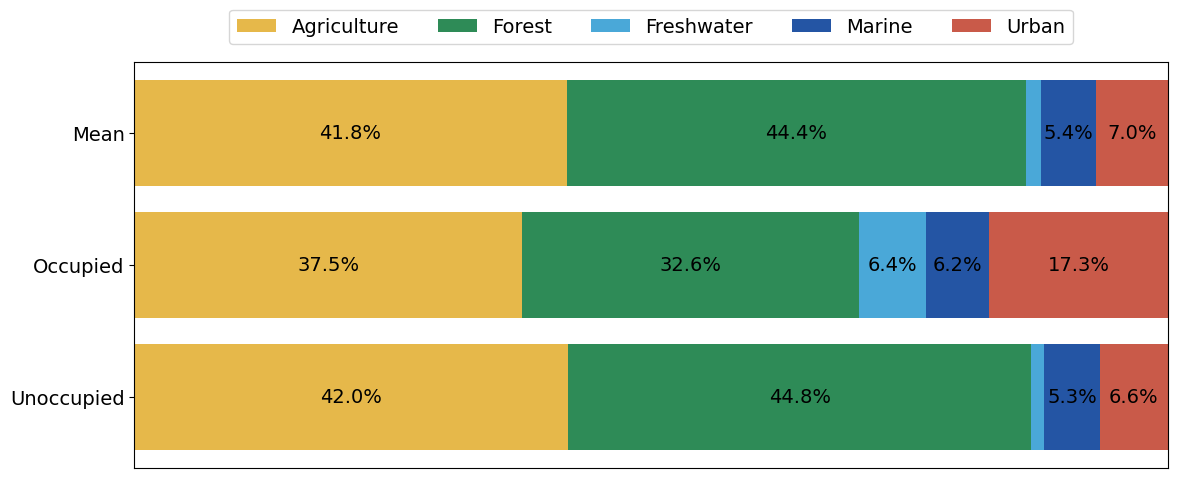

In [ ]:
plt.rcParams.update({
    "font.size": 14
})



land_types = [
    "Agriculture",
    "Forest",
    "Freshwater",
    "Marine",
    "Urban"
]

prop_cols = [
    "Agriculture_prop",
    "Forest_prop",
    "Freshwater_prop",
    "Marine_prop",
    "Urban_prop"
]

pure_colours = {
    "Agriculture": "#E6B84A",
    "Forest": "#2E8B57",
    "Freshwater": "#4AA8D8",
    "Marine": "#2455A4",
    "Urban": "#C95A49"
}

bar_data = pd.DataFrame(
    {
        "Mean": grid_land3035[prop_cols].mean().values,

        "Occupied": grid_land3035.loc[
            grid_land3035["occyear2"] == 1,
            prop_cols
        ].mean().values,

        "Unoccupied": grid_land3035.loc[
            grid_land3035["occyear2"] == 0,
            prop_cols
        ].mean().values
    },
    index=land_types
).T

print(bar_data)
print(bar_data.sum(axis=1))


fig, ax = plt.subplots(figsize=(12, 5))

left = np.zeros(len(bar_data))

for land_type in land_types:

    values = bar_data[land_type].to_numpy()

    ax.barh(
        bar_data.index,
        values,
        left=left,
        color=pure_colours[land_type],
        edgecolor="none",

        label=land_type
    )

    # Percentage labels
    for i, value in enumerate(values):

        if value >= 0.03:
            ax.text(
                left[i] + value / 2,
                i,
                f"{value * 100:.1f}%",
                ha="center",
                va="center",
                # color="white",
                fontsize=14
            )

    left += values



ax.set_xlim(0, 1)

ax.set_xticks([])

# ax.set_title(
#     "Land-cover proportion"
# )

ax.invert_yaxis()

ax.legend(
    title=None,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=True
)
plt.tight_layout()



### --save the image
output_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_landcover_composition.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()